# ESTUDIO DEL AUMENTO DEL PARQUE VEHICULAR LIVIANO Y EL DETERIORO EN LA CALIDAD DEL AIRE CON PM2.5 EN GUATEMALA, GUATEMALA 2022-2025

## Fase 1: Entendimiento del Negocio / Investigación

**Tesis:** *ESTUDIO DEL AUMENTO DEL PARQUE VEHICULAR LIVIANO Y EL DETERIORO EN LA CALIDAD DEL AIRE CON PM2.5 EN GUATEMALA, GUATEMALA 2022-2025.*

### Contexto y justificación
Las partículas finas (PM2.5, diámetro aerodinámico < 2.5 µm) constituyen uno de los contaminantes atmosféricos con mayor impacto documentado en la salud pública. En ciudades latinoamericanas con alta densidad vehicular y flota antigua, el tráfico rodado es la principal fuente de emisión de PM2.5. Guatemala City ha experimentado un crecimiento sostenido de su parque vehicular liviano (automóviles, pick-ups, motocicletas, SUVs), lo que plantea la hipótesis central de esta investigación.

### Objetivos analíticos
1. Describir la evolución temporal del parque vehicular liviano y los niveles de PM2.5 durante el período 2022-2025.
2. Modelar la serie temporal de PM2.5 mediante ARIMA y SARIMAX, incorporando el volumen vehicular como variable exógena.
3. Cuantificar y contrastar correlaciones entre PM2.5 mensual y el parque vehicular segmentado por modelo, tipo y línea de vehículo.

### Marco metodológico
Se aplica **CRISP-DM** (Cross-Industry Standard Process for Data Mining) como marco rector del análisis, garantizando trazabilidad y reproducibilidad académica.
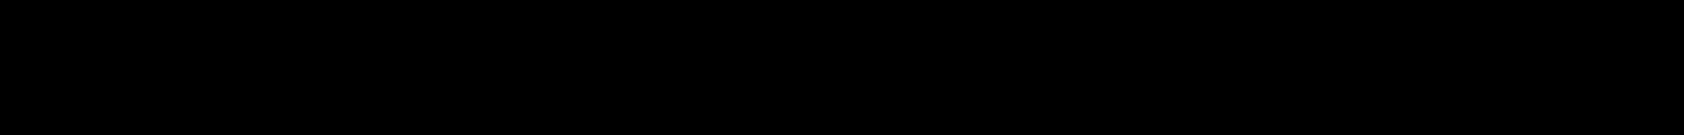

## Fase 2: Entendimiento de los Datos

### 2.1 Carga de librerías

In [55]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro, jarque_bera
import dataframe_image as dfi

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### 2.2 Carga de datos

In [2]:
PATH_VEH = 'Data/Vehiculos/PARQUE-VEHICULAR-2007-2025-FULL.csv'
PATH_PM  = 'Data/PM25/PM25_DAIRY_FULL_2022_2025.csv'


df_veh = pd.read_csv(PATH_VEH, low_memory=False)
df_pm  = pd.read_csv(PATH_PM)


print(f"Parque vehicular — filas: {len(df_veh):,}  |  columnas: {df_veh.shape[1]}")
print(f"PM2.5            — filas: {len(df_pm):,}  |  columnas: {df_pm.shape[1]}")

Parque vehicular — filas: 499,743  |  columnas: 7
PM2.5            — filas: 1,380  |  columnas: 4


### 2.3 Exploración inicial — Parque Vehicular

In [3]:
display(df_veh.head(3))
print("\nTipos de datos:")
display(df_veh.dtypes.to_frame('dtype'))
print("\nValores nulos:")
display(df_veh.isnull().sum().to_frame('nulos'))
print("\nEstadísticas descriptivas (CANTIDAD):")
display(df_veh['CANTIDAD'].describe().to_frame())

,ANIO_ALZA,MES,MODELO_VEHICULO,LINEA_VEHICULO,TIPO_VEHICULO,MARCA_VEHICULO,CANTIDAD
0,2007,5,2003,SANTA FE V6 4X2,CAMIONETA,HYUNDAI,1
1,2007,5,2001,SWIFT,AUTOMOVIL,SUZUKI,1
2,2007,5,1995,METRO LSI,AUTOMOVIL,GEO,1



Tipos de datos:


,dtype
ANIO_ALZA,int64
MES,int64
MODELO_VEHICULO,str
LINEA_VEHICULO,str
TIPO_VEHICULO,str
MARCA_VEHICULO,str
CANTIDAD,int64



Valores nulos:


,nulos
ANIO_ALZA,0
MES,0
MODELO_VEHICULO,0
LINEA_VEHICULO,0
TIPO_VEHICULO,0
MARCA_VEHICULO,0
CANTIDAD,0



Estadísticas descriptivas (CANTIDAD):


,CANTIDAD
count,"499,743.0000"
mean,2.8594
std,15.1100
min,1.0000
25%,1.0000
50%,1.0000
75%,2.0000
max,"1,889.0000"


### 2.4 Exploración inicial — PM2.5

In [4]:
display(df_pm.head(3))
print("\nTipos de datos:")
display(df_pm.dtypes.to_frame('dtype'))
print("\nValores nulos:")
display(df_pm.isnull().sum().to_frame('nulos'))
print("\nEstadísticas descriptivas PM2.5 (μg/m³):")
display(df_pm['PM25'].describe().to_frame())

,YEAR,MONTH,DAY,PM25
0,2022,3,4,4.6000
1,2022,3,7,42.0000
2,2022,3,8,55.0000



Tipos de datos:


,dtype
YEAR,int64
MONTH,int64
DAY,int64
PM25,float64



Valores nulos:


,nulos
YEAR,0
MONTH,0
DAY,0
PM25,0



Estadísticas descriptivas PM2.5 (μg/m³):


,PM25
count,"1,380.0000"
mean,30.4328
std,42.2411
min,0.8000
25%,9.1000
50%,18.1500
75%,37.1250
max,"1,016.0000"


### 2.5 Distribución global de PM2.5 (serie diaria completa)

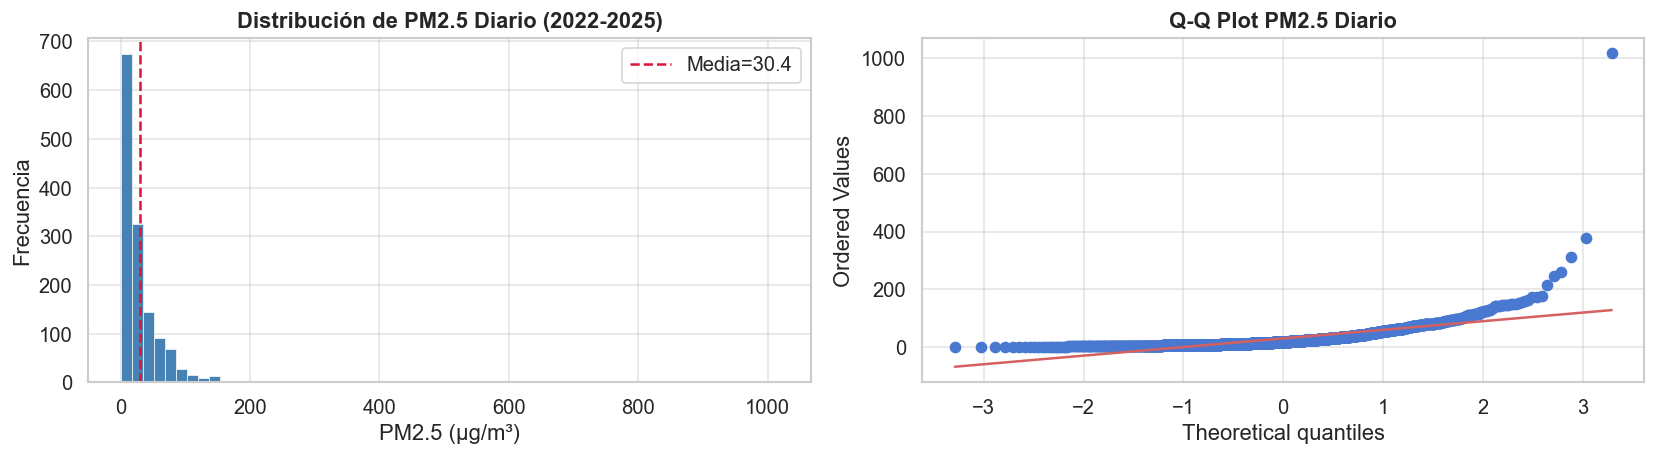

Rango temporal: 2022-03 → 2025-12


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_pm['PM25'].dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribución de PM2.5 Diario (2022-2025)', fontweight='bold')
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_pm['PM25'].mean(), color='crimson', linestyle='--', label=f'Media={df_pm["PM25"].mean():.1f}')
axes[0].legend()

stats.probplot(df_pm['PM25'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot PM2.5 Diario', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rango temporal: {df_pm['YEAR'].min()}-{int(df_pm['MONTH'][df_pm['YEAR']==df_pm['YEAR'].min()].min()):02d} "
      f"→ {df_pm['YEAR'].max()}-{int(df_pm['MONTH'][df_pm['YEAR']==df_pm['YEAR'].max()].max()):02d}")

## Fase 3: Preparación de los Datos

### 3.1 PM2.5 — Media mensual (Marzo 2022 – Diciembre 2025)

Se construye una columna `DATE` tipo datetime, se filtra el período de estudio y se remuestrea agrupando por año-mes para obtener la **media mensual** de PM2.5.

In [6]:
df_pm['DATE'] = pd.to_datetime(dict(year=df_pm['YEAR'], month=df_pm['MONTH'], day=df_pm['DAY']))
df_pm_f = df_pm[(df_pm['DATE'] >= '2022-03-01') & (df_pm['DATE'] <= '2025-12-31')].copy()

# ── CORRECCIÓN: eliminar outlier físicamente imposible (1,016 µg/m³) ──
# Una media DIARIA de PM2.5 > 500 µg/m³ no es plausible en este contexto
# (error de sensor/captura). Se descarta antes de promediar por mes.
n_antes = len(df_pm_f)
df_pm_f = df_pm_f[df_pm_f['PM25'] < 500].copy()
print(f"Lecturas diarias descartadas por outlier (>500 µg/m³): {n_antes - len(df_pm_f)}")

pm_mensual = (df_pm_f.groupby(['YEAR','MONTH'])['PM25']
              .mean()
              .reset_index()
              .rename(columns={'PM25':'PM25_MEAN'}))

pm_mensual['PERIOD'] = pd.to_datetime(
    pm_mensual['YEAR'].astype(str) + '-' + pm_mensual['MONTH'].astype(str).str.zfill(2))
pm_mensual = pm_mensual.sort_values('PERIOD').reset_index(drop=True)

print(f"Registros mensuales PM2.5 (reales, sin imputar): {len(pm_mensual)}")
print(f"Serie inicia: {pm_mensual['PERIOD'].min():%Y-%m}")
display(pm_mensual.head(6))

Lecturas diarias descartadas por outlier (>500 µg/m³): 1
Registros mensuales PM2.5 (reales, sin imputar): 46
Serie inicia: 2022-03


,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,3,36.2192,2022-03-01
1,2022,4,34.6538,2022-04-01
2,2022,5,35.0429,2022-05-01
3,2022,6,18.1700,2022-06-01
4,2022,7,11.1000,2022-07-01
5,2022,8,21.2333,2022-08-01


> **Nota metodológica (corrección):** En la versión anterior se imputaban
> Enero y Febrero 2022 con el promedio de esos mismos meses en otros años y se
> almacenaban en una variable llamada `predicciones_2022`. Esto introducía
> valores sintéticos tratados luego como datos observados, sesgando el modelo.
>
> **Decisión:** se trabaja con la serie **real** disponible (marzo 2022 en
> adelante). El estudio conserva así la integridad de los datos observados.
> Si el comité exigiera la rejilla mensual completa, la imputación debe
> declararse explícitamente como tal en la sección de limitaciones, nunca
> como observación.

### 3.2 Parque Vehicular — Altas mensuales (Enero 2022 – Diciembre 2025)

Se filtran únicamente los registros cuyo año/mes de alta (`ANIO_ALZA`, `MES`) caen dentro del período de estudio. Se suma `CANTIDAD` para obtener el total de vehículos que ingresaron a circulación cada mes.

In [7]:
df_veh['ANIO_ALZA'] = pd.to_numeric(df_veh['ANIO_ALZA'], errors='coerce')
df_veh['MES']       = pd.to_numeric(df_veh['MES'],       errors='coerce')
df_veh.dropna(subset=['ANIO_ALZA','MES'], inplace=True)
df_veh['ANIO_ALZA'] = df_veh['ANIO_ALZA'].astype(int)
df_veh['MES']       = df_veh['MES'].astype(int)

df_veh['PERIOD_ALTA'] = pd.to_datetime(
    df_veh['ANIO_ALZA'].astype(str) + '-' + df_veh['MES'].astype(str).str.zfill(2))

mask = (df_veh['PERIOD_ALTA'] >= '2022-01-01') & (df_veh['PERIOD_ALTA'] <= '2025-12-31')
df_altas = df_veh[mask].copy()

mask2 = (df_veh['PERIOD_ALTA'] >= '1980-01-01') & (df_veh['PERIOD_ALTA'] <= '2025-12-31')
df_acum = df_veh[mask2].copy()

altas_mensual = (df_altas.groupby('PERIOD_ALTA')['CANTIDAD']
                 .sum()
                 .reset_index()
                 .rename(columns={'PERIOD_ALTA':'PERIOD', 'CANTIDAD':'ALTAS_MENS'}))
altas_mensual = altas_mensual.sort_values('PERIOD').reset_index(drop=True)

print(f"Meses con altas en período de estudio: {len(altas_mensual)}")
print(f"Total vehículos ingresados 2022-2025: {altas_mensual['ALTAS_MENS'].sum():,}")
display(altas_mensual.head(6))

Meses con altas en período de estudio: 48
Total vehículos ingresados 2022-2025: 487,587


,PERIOD,ALTAS_MENS
0,2022-01-01,8823
1,2022-02-01,8520
2,2022-03-01,9019
3,2022-04-01,8897
4,2022-05-01,9418
5,2022-06-01,10737


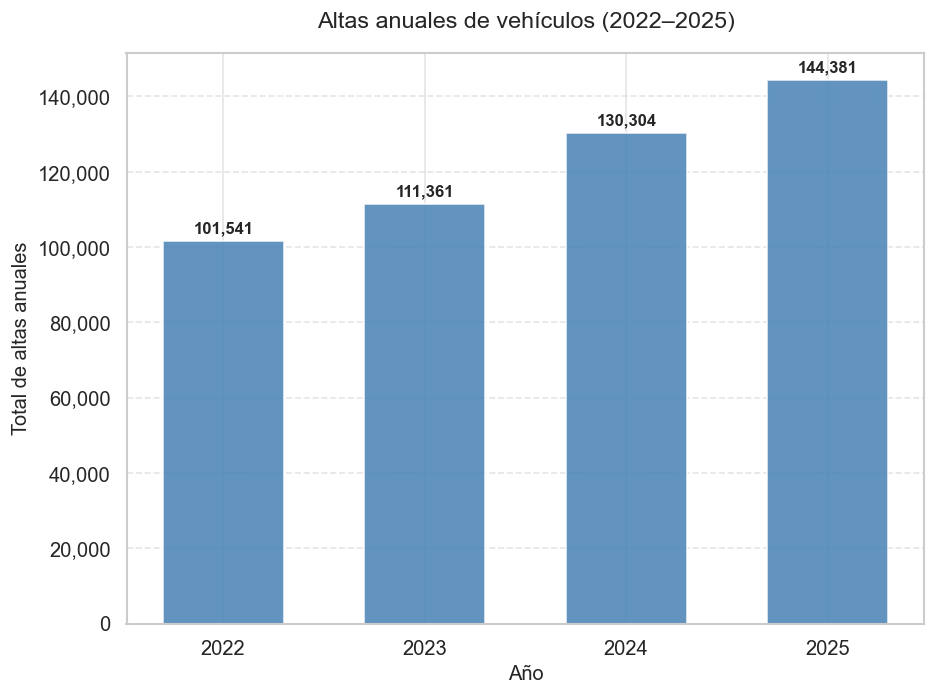

In [8]:
# 1. Asegurar que 'PERIOD' sea de tipo datetime (si no lo es ya)
altas_mensual['PERIOD'] = pd.to_datetime(altas_mensual['PERIOD'])

# 2. Agrupar los datos por año sumando la cantidad de vehículos
#    (Usamos la columna 'ALTAS_MENS' para consolidar el total del año)
altas_anual = altas_mensual.groupby(altas_mensual['PERIOD'].dt.year)['ALTAS_MENS'].sum().reset_index()
altas_anual.columns = ['ANIO', 'TOTAL_ANUAL']

# 3. Graficar
plt.figure(figsize=(8, 6))
bars = plt.bar(altas_anual['ANIO'].astype(str), altas_anual['TOTAL_ANUAL'],
               color='steelblue', alpha=0.85, width=0.6)

plt.title('Altas anuales de vehículos (2022–2025)', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de altas anuales', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Formatear el eje Y con comas para los miles
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Añadir etiquetas de datos arriba de cada barra para que sea ultra legible
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 puntos de desfase vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

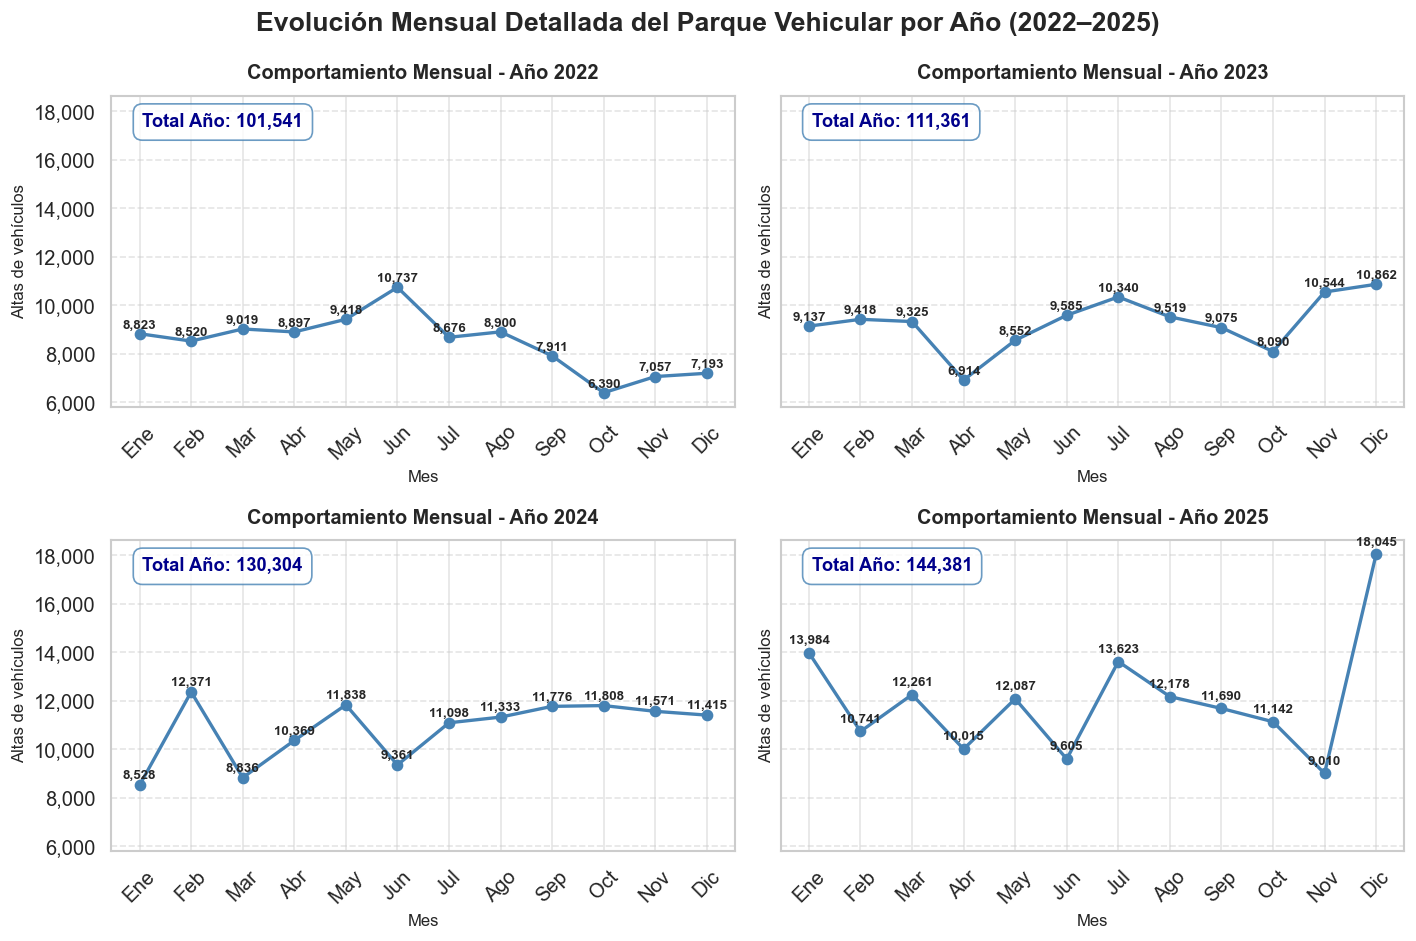

In [9]:
# 1. Asegurar formato de fecha y extraer Año y Mes
altas_mensual['PERIOD'] = pd.to_datetime(altas_mensual['PERIOD'])
altas_mensual['ANIO'] = altas_mensual['PERIOD'].dt.year
altas_mensual['MES'] = altas_mensual['PERIOD'].dt.month

# Lista de años únicos a graficar
anios = sorted(altas_mensual['ANIO'].unique())

# 2. Configurar la matriz de gráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.flatten()

# Lista de nombres de meses abreviados para el eje X
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

for i, anio in enumerate(anios):
    ax = axes[i]

    # Filtrar los datos para el año en curso
    datos_anio = altas_mensual[altas_mensual['ANIO'] == anio].sort_values('MES')

    # Calcular el total del año para mostrarlo en la gráfica
    total_del_anio = datos_anio['ALTAS_MENS'].sum()

    # --- CAMBIO: Dibujamos la línea con marcadores ---
    ax.plot(datos_anio['MES'], datos_anio['ALTAS_MENS'],
            color='steelblue', marker='o', linestyle='-', linewidth=2, markersize=6, label=f'Altas {anio}')

    # --- NUEVO: Etiquetas sobre cada punto de la línea ---
    for x, y in zip(datos_anio['MES'], datos_anio['ALTAS_MENS']):
        ax.text(x, y + (max(datos_anio['ALTAS_MENS'])*0.02), f'{y:,.0f}',
                fontsize=8, ha='center', weight='bold')

    # Agregar el recuadro con el total anual
    ax.text(0.05, 0.90, f'Total Año: {total_del_anio:,.0f}',
            transform=ax.transAxes, fontsize=11, weight='bold', color='darkblue',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='steelblue', boxstyle='round,pad=0.5'))

    # Títulos y etiquetas (se mantienen iguales)
    ax.set_title(f'Comportamiento Mensual - Año {anio}', fontsize=12, weight='bold', pad=10)
    ax.set_xlabel('Mes', fontsize=10)
    ax.set_ylabel('Altas de vehículos', fontsize=10)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(nombres_meses, rotation=45)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Ajustes estéticos globales
plt.suptitle('Evolución Mensual Detallada del Parque Vehicular por Año (2022–2025)',
             fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 3.3 Parque Vehicular — Inventario ACUMULADO circulante

El parque circulante real en cada mes es el acumulado histórico de todos los vehículos que han ingresado hasta ese período. Se calcula con un `cumsum()` sobre las altas mensuales dentro del período de estudio.

In [10]:
altas_mensual_acum = (df_acum.groupby('PERIOD_ALTA')['CANTIDAD']
                 .sum()
                 .reset_index()
                 .rename(columns={'PERIOD_ALTA':'PERIOD', 'CANTIDAD':'ALTAS_MENS'}))

altas_mensual_acum = altas_mensual_acum.sort_values('PERIOD').reset_index(drop=True)
altas_mensual_acum['ACUMULADO'] = altas_mensual_acum['ALTAS_MENS'].cumsum()
print("Parque vehicular acumulado al final del período:")
print(f"  {altas_mensual_acum['ACUMULADO'].iloc[-1]:,} vehículos")
display(altas_mensual_acum.tail(6))

Parque vehicular acumulado al final del período:
  1,428,967 vehículos


,PERIOD,ALTAS_MENS,ACUMULADO
423,2025-07-01,13623,1366902
424,2025-08-01,12178,1379080
425,2025-09-01,11690,1390770
426,2025-10-01,11142,1401912
427,2025-11-01,9010,1410922
428,2025-12-01,18045,1428967


In [11]:
pm_mensual.head(3)

,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,3,36.2192,2022-03-01
1,2022,4,34.6538,2022-04-01
2,2022,5,35.0429,2022-05-01


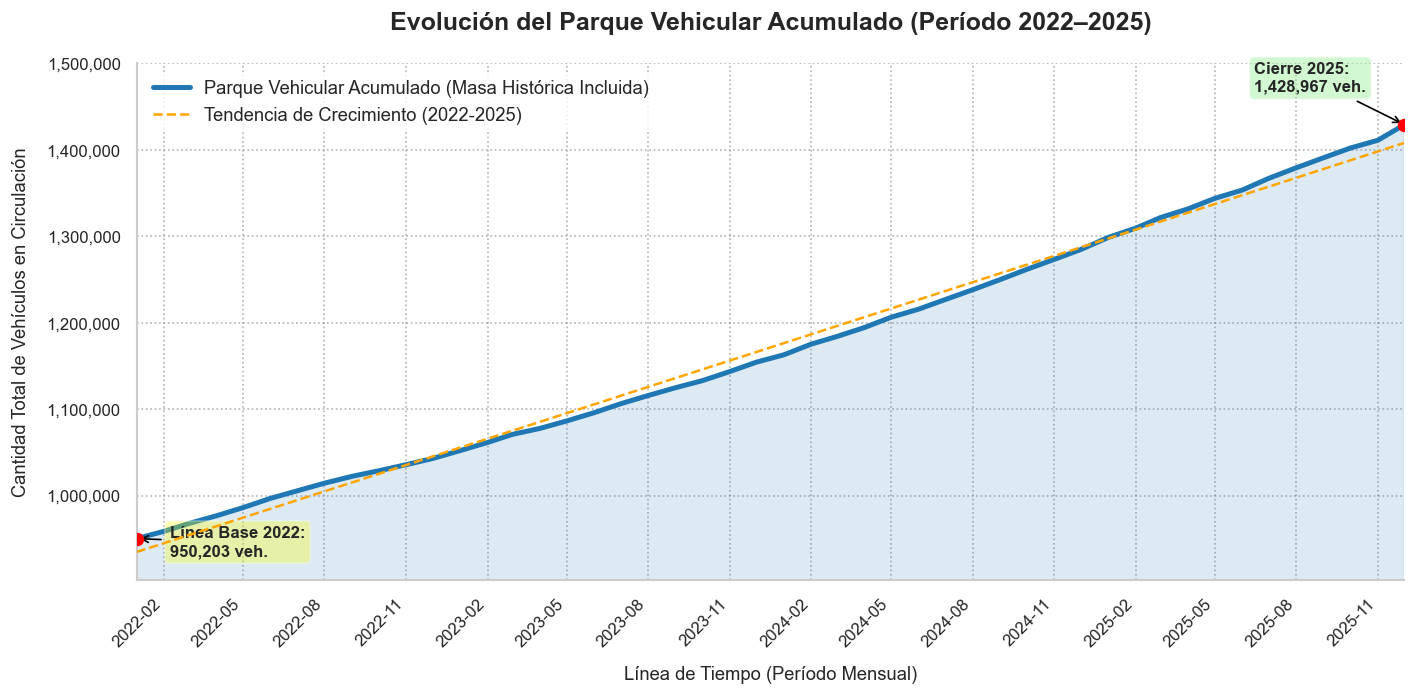

In [12]:
# 1. Asegurar formato de fecha
altas_mensual_acum['PERIOD'] = pd.to_datetime(altas_mensual_acum['PERIOD'])

# --- LOGICA CORREGIDA ---
# Primero: Ordenamos cronológicamente y calculamos el acumulado HISTÓRICO TOTAL
altas_mensual_acum = altas_mensual_acum.sort_values('PERIOD').reset_index(drop=True)
altas_mensual_acum['ACUMULADO'] = altas_mensual_acum['ALTAS_MENS'].cumsum()

# Segundo: AHORA SÍ filtramos el dataset para quedarnos ÚNICAMENTE con el período visual de la tesis
df_grafico = altas_mensual_acum[
    (altas_mensual_acum['PERIOD'] >= '2022-01-01') &
    (altas_mensual_acum['PERIOD'] <= '2025-12-31')
].copy()
# ------------------------

# 2. Configuración de la figura
plt.figure(figsize=(12, 6), facecolor='white')
ax = plt.gca()

# 3. Graficar la curva principal utilizando el DataFrame filtrado (pero con la masa histórica calculada)
plt.plot(df_grafico['PERIOD'], df_grafico['ACUMULADO'],
         color='#1f77b4', linewidth=3, label='Parque Vehicular Acumulado (Masa Histórica Incluida)', zorder=3)

plt.fill_between(df_grafico['PERIOD'], df_grafico['ACUMULADO'],
                 color='#1f77b4', alpha=0.15, zorder=2)

# 4. Línea de tendencia promedio basada en el comportamiento 2022–2025
y = df_grafico['ACUMULADO']
m, b = np.polyfit(mdates.date2num(df_grafico['PERIOD']), y, 1)
plt.plot(df_grafico['PERIOD'], m * mdates.date2num(df_grafico['PERIOD']) + b,
         color='orange', linestyle='--', linewidth=1.5, label='Tendencia de Crecimiento (2022-2025)', zorder=4)

# 5. ANOTACIONES: Extremos reales del período de la tesis
# Punto Inicial (Enero 2022 - Mostrará el acumulado heredado de años anteriores)
p_inicio_x = df_grafico['PERIOD'].iloc[0]
p_inicio_y = df_grafico['ACUMULADO'].iloc[0]
plt.scatter(p_inicio_x, p_inicio_y, color='red', s=50, zorder=5)
ax.annotate(f'Línea Base 2022:\n{p_inicio_y:,.0f} veh.',
            xy=(p_inicio_x, p_inicio_y), xytext=(20, -10),
            textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, weight='bold')

# Punto Final (Diciembre 2025)
p_final_x = df_grafico['PERIOD'].iloc[-1]
p_final_y = df_grafico['ACUMULADO'].iloc[-1]
plt.scatter(p_final_x, p_final_y, color='red', s=50, zorder=5)
ax.annotate(f'Cierre 2025:\n{p_final_y:,.0f} veh.',
            xy=(p_final_x, p_final_y), xytext=(-90, 20),
            textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.4),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, weight='bold')

# Forzar los límites visuales exactos del eje X para que empiece en 2022 y cierre en 2025
ax.set_xlim(df_grafico['PERIOD'].min(), df_grafico['PERIOD'].max())

# Ajustar el límite inferior de Y para que la gráfica no empiece desde 0 de forma innecesaria,
# permitiendo apreciar mejor la pendiente de crecimiento a partir del volumen heredado.
ax.set_ylim(df_grafico['ACUMULADO'].min() * 0.95, df_grafico['ACUMULADO'].max() * 1.05)

# 6. Formateo estricto de los Ejes
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right', fontsize=10)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.yticks(fontsize=10)

# 7. Títulos, Leyendas y Limpieza Visual
plt.title('Evolución del Parque Vehicular Acumulado (Período 2022–2025)', fontsize=15, weight='bold', pad=20)
plt.xlabel('Línea de Tiempo (Período Mensual)', fontsize=11, labelpad=10)
plt.ylabel('Cantidad Total de Vehículos en Circulación', fontsize=11, labelpad=10)

plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.legend(loc='upper left', fontsize=11, frameon=True, facecolor='white', edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

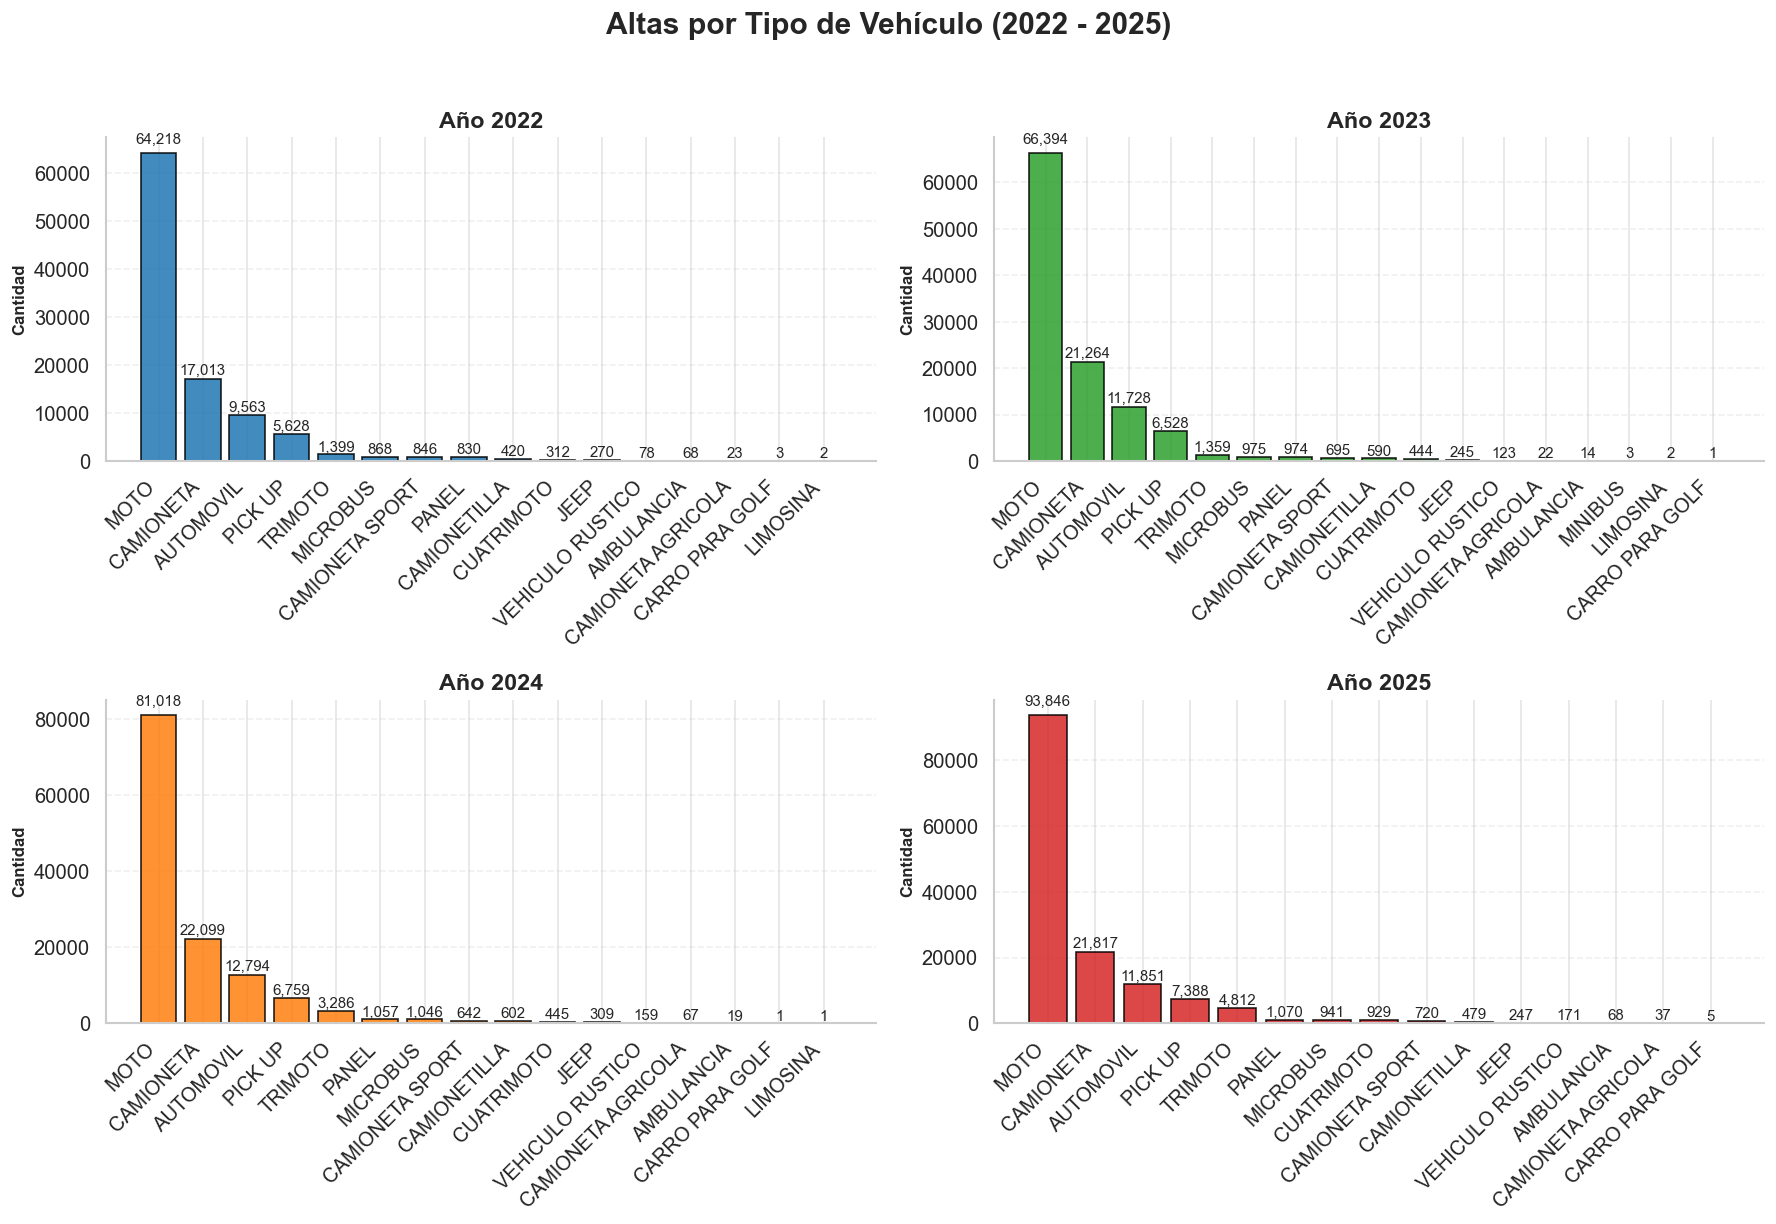

In [13]:

# 1. Filtrar los datos base
df_altas_tipo_vehiculo = df_veh[(df_veh['ANIO_ALZA'] >= 2022) & (df_veh['ANIO_ALZA'] <= 2025)]

# 2. Agrupar por Año y Tipo de Vehículo
df_agrupado_anio = df_altas_tipo_vehiculo.groupby(['ANIO_ALZA', 'TIPO_VEHICULO'])['CANTIDAD'].sum().reset_index()

# 3. Crear el panel (figura) con 4 subgráficas (2x2)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Altas por Tipo de Vehículo (2022 - 2025)', fontsize=18, fontweight='bold', y=1.02)

# Lista de años y paleta de colores para diferenciar cada año
anios = [2022, 2023, 2024, 2025]
colores = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# Aplanar la matriz de ejes (axes) para poder iterar sobre ellos fácilmente en un solo bucle
axes = axes.flatten()

# 4. Bucle para generar cada gráfica por año
for i, anio in enumerate(anios):
    ax = axes[i]

    # Filtrar los datos exclusivamente para el año actual del bucle
    df_anio = df_agrupado_anio[df_agrupado_anio['ANIO_ALZA'] == anio].copy()

    # Ordenar de mayor a menor para mejor lectura
    df_anio = df_anio.sort_values('CANTIDAD', ascending=False)

    # Crear la gráfica de barras en su panel correspondiente (ax)
    ax.bar(df_anio['TIPO_VEHICULO'], df_anio['CANTIDAD'],
           color=colores[i], edgecolor='black', alpha=0.85)

    # Formateo del título y ejes del sub-panel
    ax.set_title(f'Año {anio}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cantidad', fontsize=10, fontweight='bold')

    # Rotar las etiquetas del eje X a 45 grados y alinearlas
    ax.set_xticks(range(len(df_anio['TIPO_VEHICULO'])))
    ax.set_xticklabels(df_anio['TIPO_VEHICULO'], rotation=45, ha='right')

    # Estética y limpieza
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Agregar el valor numérico encima de cada barra
    for j, valor in enumerate(df_anio['CANTIDAD']):
        ax.text(j, valor + (valor * 0.02), f'{int(valor):,}',
                ha='center', va='bottom', fontsize=9)

# 5. Ajuste final para evitar superposiciones de texto
plt.tight_layout()
plt.show()

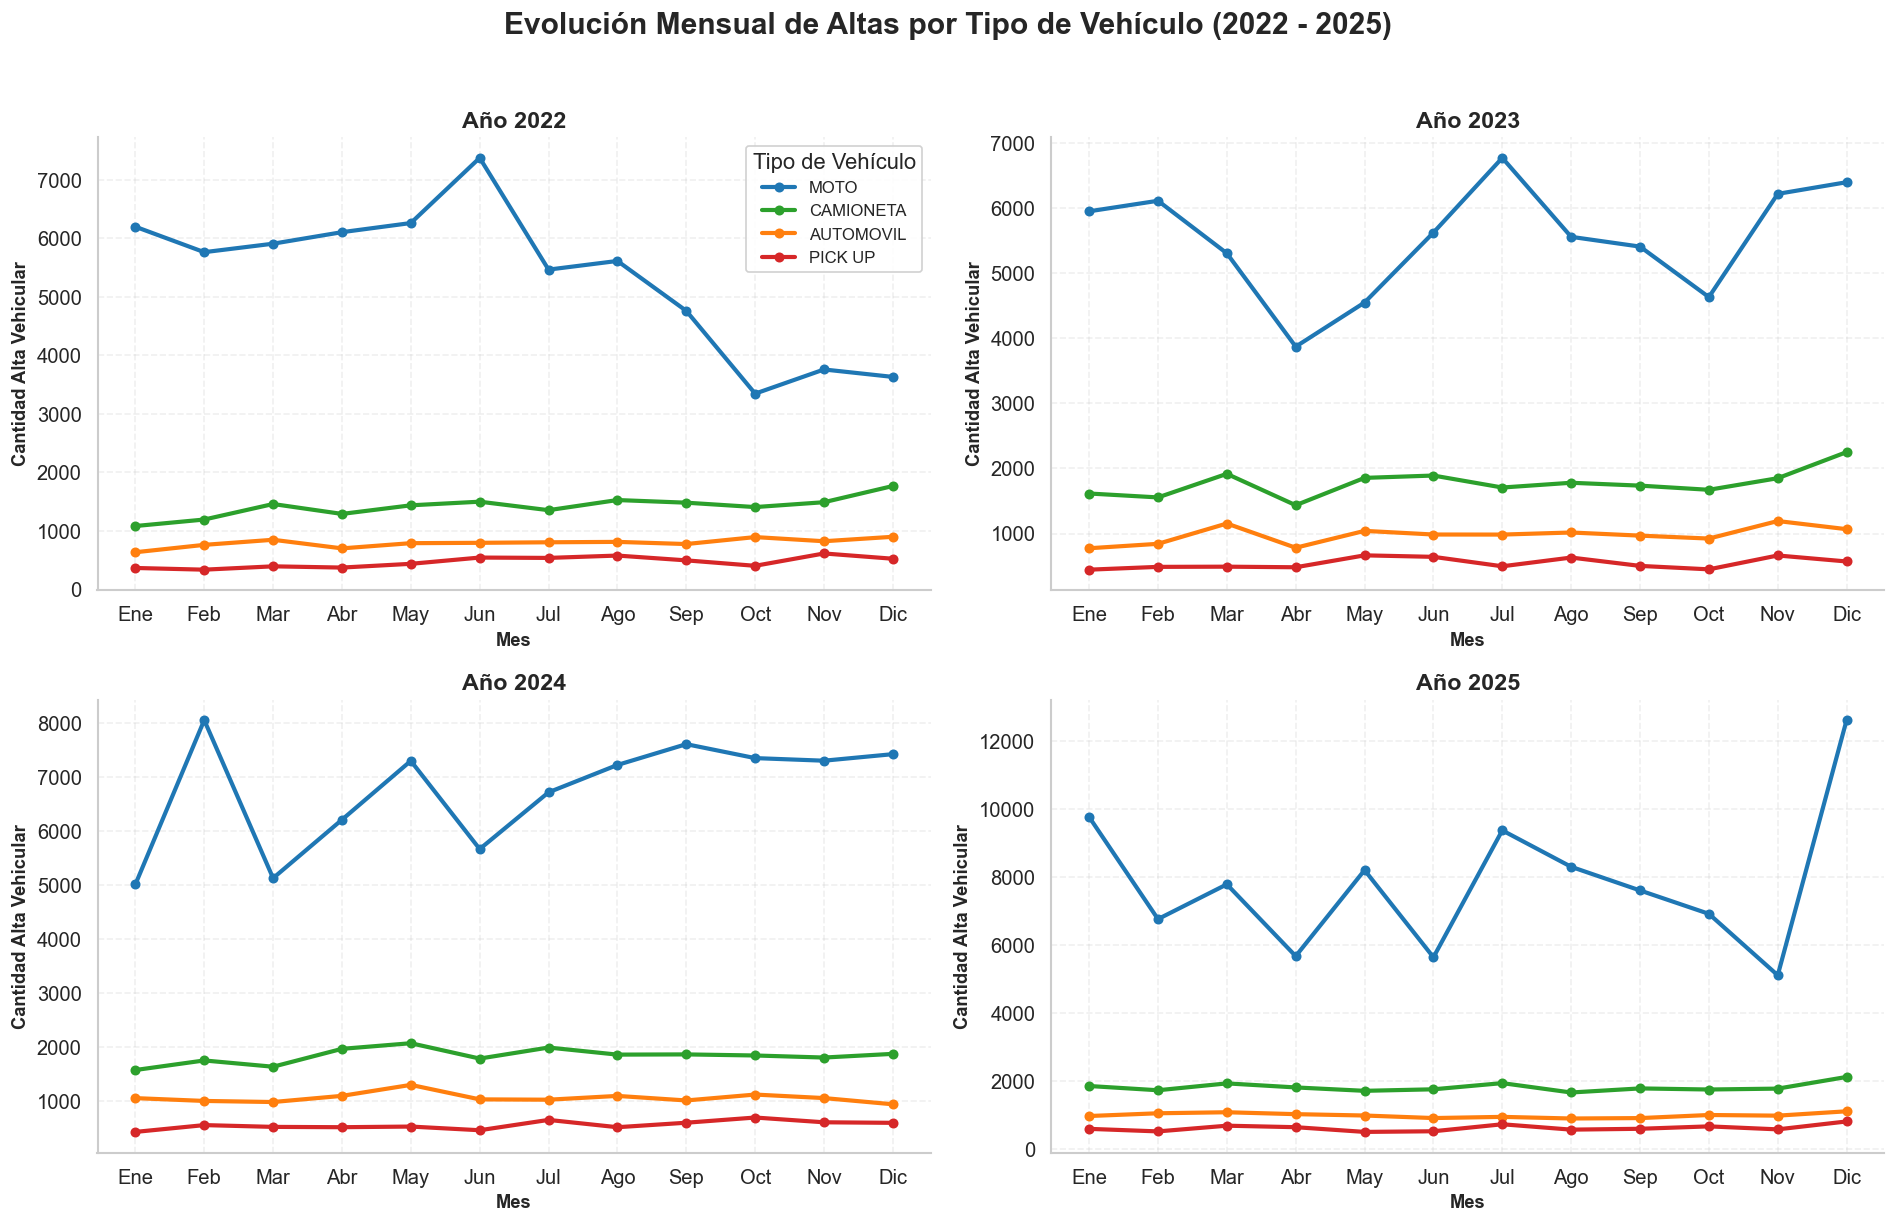

In [14]:
# 1. Definir los filtros
anios = [2022, 2023, 2024, 2025]
tipos_deseados = ["MOTO", "CAMIONETA", "AUTOMOVIL", "PICK UP"]
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Diccionario de colores para mantener consistencia visual en todos los paneles
colores_veh = {
    'MOTO': '#1f77b4',      # Azul
    'CAMIONETA': '#2ca02c', # Verde
    'AUTOMOVIL': '#ff7f0e', # Naranja
    'PICK UP': '#d62728'    # Rojo
}

# 2. Filtrar el DataFrame original (por años y por los 4 tipos de vehículos)
df_filtrado = df_veh[
    (df_veh['ANIO_ALZA'].isin(anios)) &
    (df_veh['TIPO_VEHICULO'].isin(tipos_deseados))
]

# 3. Agrupar sumando la cantidad por Año, Mes y Tipo de Vehículo
df_agrupado = df_filtrado.groupby(['ANIO_ALZA', 'MES', 'TIPO_VEHICULO'])['CANTIDAD'].sum().reset_index()

# 4. Crear el panel (2 filas x 2 columnas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('Evolución Mensual de Altas por Tipo de Vehículo (2022 - 2025)',
             fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()

# 5. Iterar sobre los años para crear cada sub-gráfica
for i, anio in enumerate(anios):
    ax = axes[i]

    # Aislar los datos del año actual
    df_anio = df_agrupado[df_agrupado['ANIO_ALZA'] == anio]

    # Pivotar los datos: Meses en las filas (índice), Tipos en las columnas
    df_pivot = df_anio.pivot(index='MES', columns='TIPO_VEHICULO', values='CANTIDAD')

    # Trazar una línea por cada tipo de vehículo
    for tipo in tipos_deseados:
        if tipo in df_pivot.columns: # Validar que haya datos de ese vehículo en ese año
            ax.plot(df_pivot.index, df_pivot[tipo],
                    marker='o', markersize=5, linewidth=2.5,
                    color=colores_veh[tipo], label=tipo)

    # Formateo del sub-panel
    ax.set_title(f'Año {anio}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cantidad Alta Vehicular', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mes', fontsize=11, fontweight='bold')

    # Configuración del eje X (1 al 12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(nombres_meses)

    # Estética y limpieza
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Agregar la leyenda solo en el primer panel para no saturar la imagen
    if i == 0:
        ax.legend(title='Tipo de Vehículo', fontsize=10, loc='best',
                  framealpha=0.9, edgecolor='#cccccc')

# 6. Ajuste fino y visualización
plt.tight_layout()
plt.show()

### 3.4 Dataset consolidado (merge por período mensual)

In [15]:
pm_mensual.head(50)

,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,3,36.2192,2022-03-01
1,2022,4,34.6538,2022-04-01
2,2022,5,35.0429,2022-05-01
3,2022,6,18.1700,2022-06-01
4,2022,7,11.1000,2022-07-01
5,2022,8,21.2333,2022-08-01
6,2022,9,29.6500,2022-09-01
7,2022,10,26.2871,2022-10-01
8,2022,11,20.2233,2022-11-01
9,2022,12,22.3839,2022-12-01


In [16]:
print(pm_mensual['PM25_MEAN'].tail(50)[::-1].to_string(index=False))

19.4433
12.7733
15.8806
24.1867
15.6290
 8.2935
17.9100
47.9806
25.1867
32.4742
15.3786
12.3067
 9.3484
15.3567
20.5387
28.5533
11.2645
12.0226
34.5367
93.1516
93.0067
92.7484
44.0778
49.1677
42.9484
15.5633
11.7484
13.4867
15.1290
12.4871
38.1621
60.2032
62.9600
39.9742
17.8130
29.3645
22.3839
20.2233
26.2871
29.6500
21.2333
11.1000
18.1700
35.0429
34.6538
36.2192


#### Estimacion de valores para enero y febrero


In [17]:
pm_mensual.head(20)

,YEAR,MONTH,PM25_MEAN,PERIOD
0,2022,3,36.2192,2022-03-01
1,2022,4,34.6538,2022-04-01
2,2022,5,35.0429,2022-05-01
3,2022,6,18.1700,2022-06-01
4,2022,7,11.1000,2022-07-01
5,2022,8,21.2333,2022-08-01
6,2022,9,29.6500,2022-09-01
7,2022,10,26.2871,2022-10-01
8,2022,11,20.2233,2022-11-01
9,2022,12,22.3839,2022-12-01


In [18]:
pm_mensual_tmp=pm_mensual.copy()
pm_mensual_tmp["PERIOD"] = pd.to_datetime(pm_mensual_tmp["PERIOD"])
pm_mensual_tmp = pm_mensual_tmp.sort_values("PERIOD").reset_index(drop=True)

annual_mean = pm_mensual_tmp.groupby("YEAR")["PM25_MEAN"].mean()


growth_rate = annual_mean.pct_change().mean()

level_2023 = annual_mean.loc[2023]
level_2022 = level_2023 / (1 + growth_rate)

seasonal = pm_mensual_tmp.groupby("MONTH")["PM25_MEAN"].mean()
global_mean = pm_mensual_tmp["PM25_MEAN"].mean()

def estimate(month, year_level):
    return (year_level / global_mean) * seasonal.loc[month]

jan_2022 = estimate(1, level_2022)
feb_2022 = estimate(2, level_2022)

imputed = pd.DataFrame({
    "YEAR": [2022, 2022],
    "MONTH": [1, 2],
    "PM25_MEAN": [jan_2022, feb_2022],
    "PERIOD": pd.to_datetime(["2022-01-01", "2022-02-01"])
})

pm_mensual_tmp = pd.concat([imputed, pm_mensual_tmp], ignore_index=True)
pm_mensual_tmp = pm_mensual_tmp.sort_values("PERIOD").reset_index(drop=True)
pm_mensual=pm_mensual_tmp


In [19]:
df_merged = pd.merge(pm_mensual[['PERIOD','PM25_MEAN']],
                     altas_mensual_acum[['PERIOD','ALTAS_MENS','ACUMULADO']],
                     on='PERIOD', how='inner')
df_merged = df_merged.sort_values('PERIOD').reset_index(drop=True)
#df_merged.index = df_merged['PERIOD']

print(f"Dataset consolidado — {len(df_merged)} períodos mensuales")
print(f"Rango: {df_merged['PERIOD'].min().strftime('%Y-%m')} → {df_merged['PERIOD'].max().strftime('%Y-%m')}")
display(df_merged.head(3))

Dataset consolidado — 48 períodos mensuales
Rango: 2022-01 → 2025-12


,PERIOD,PM25_MEAN,ALTAS_MENS,ACUMULADO
0,2022-01-01,29.9052,8823,950203
1,2022-02-01,25.4379,8520,958723
2,2022-03-01,36.2192,9019,967742


### 3.5 Visualización de las series temporales consolidadas

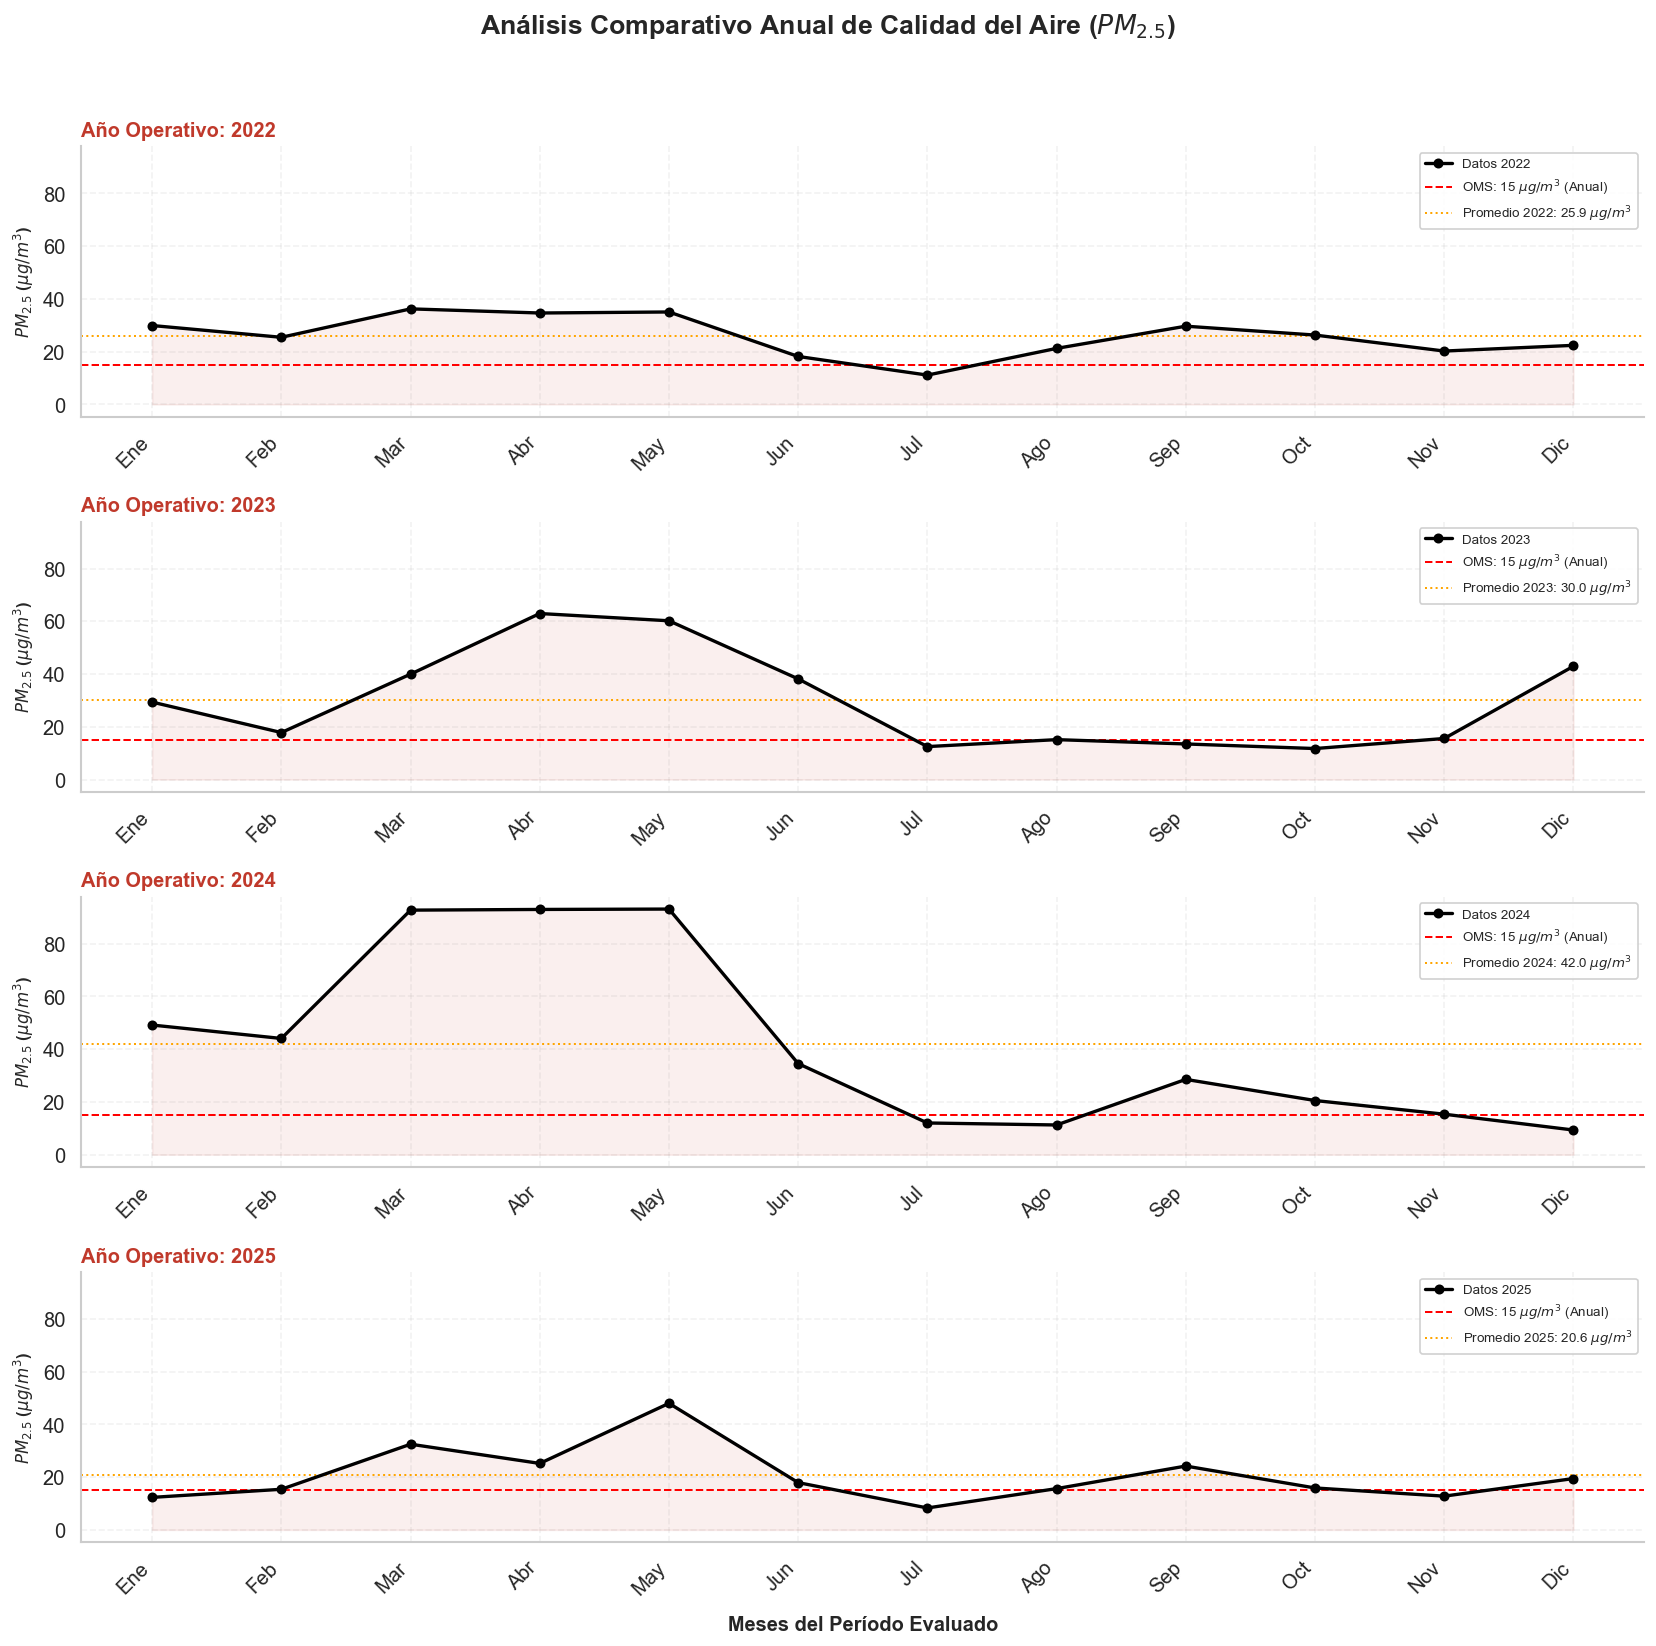

In [20]:
# 1. Asegurar la extracción de componentes temporales
df_merged['PERIOD'] = pd.to_datetime(df_merged['PERIOD'])
df_merged['ANIO'] = df_merged['PERIOD'].dt.year
df_merged['MES_NUM'] = df_merged['PERIOD'].dt.month

# Lista de años de estudio
anios = [2022, 2023, 2024, 2025]
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# 2. Crear la figura con 4 paneles verticales (uno para cada año)
# sharey=True es CRUCIAL para que la terna pueda comparar magnitudes visualmente sin engaños de escala
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True, sharey=True)
fig.suptitle('Análisis Comparativo Anual de Calidad del Aire ($PM_{2.5}$)',
             fontsize=16, fontweight='bold', y=0.98)

# Calcular el promedio histórico global para tenerlo como referencia estática en todos los paneles
prom_global = df_merged['PM25_MEAN'].mean()

# 3. Iterar sobre cada año para construir su respectivo panel
for i, anio in enumerate(anios):
    ax = axes[i]

    # Filtrar datos exclusivamente de ese año ordenados por mes
    df_anio = df_merged[df_merged['ANIO'] == anio].sort_values('MES_NUM')

    # Graficar la curva del año actual
    ax.plot(df_anio['MES_NUM'], df_anio['PM25_MEAN'],
            color='#000000', marker='o', markersize=5, linewidth=2, zorder=3, label=f'Datos {anio}')
    ax.fill_between(df_anio['MES_NUM'], df_anio['PM25_MEAN'],
                    color='#c0392b', alpha=0.08, zorder=1)

    # Líneas de referencia normativas (Guías OMS)
    ax.axhline(15, color='red', linestyle='--', linewidth=1.2, label='OMS: 15 $\mu g/m^3$ (Anual)')
    #ax.axhline(25, color='red', linestyle='--', linewidth=1.2, label='OMS: 25 $\mu g/m^3$ (24 h)')

    # Línea del promedio específico de ESE año (Información analítica extra)
    prom_anio = df_anio['PM25_MEAN'].mean()
    ax.axhline(prom_anio, color='#FFA500', linestyle=':', linewidth=1.2,
               label=f'Promedio {anio}: {prom_anio:.1f} $\mu g/m^3$')

    # Formateo de etiquetas y títulos por panel
    ax.set_ylabel('$PM_{2.5}$ ($\mu g/m^3$)', fontsize=10, fontweight='bold')
    ax.set_title(f'Año Operativo: {anio}', fontsize=12, fontweight='bold', loc='left', color='#c0392b')

    # Ubicación limpia de la leyenda
    ax.legend(fontsize=8, loc='upper right', framealpha=0.9, edgecolor='#cccccc')
    ax.grid(True, alpha=0.25, linestyle='--')

    # Configuración del eje X (Meses del año)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(nombres_meses)
    ax.tick_params(axis='x', labelbottom=True, rotation=45)

    # Alinear las etiquetas de los meses hacia la derecha
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

    # Limpieza visual de espinas estilizadas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ajuste fino final
plt.xlabel('Meses del Período Evaluado', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./Output/pm25_comparativo_anual.png', dpi=150, bbox_inches='tight')
plt.show()

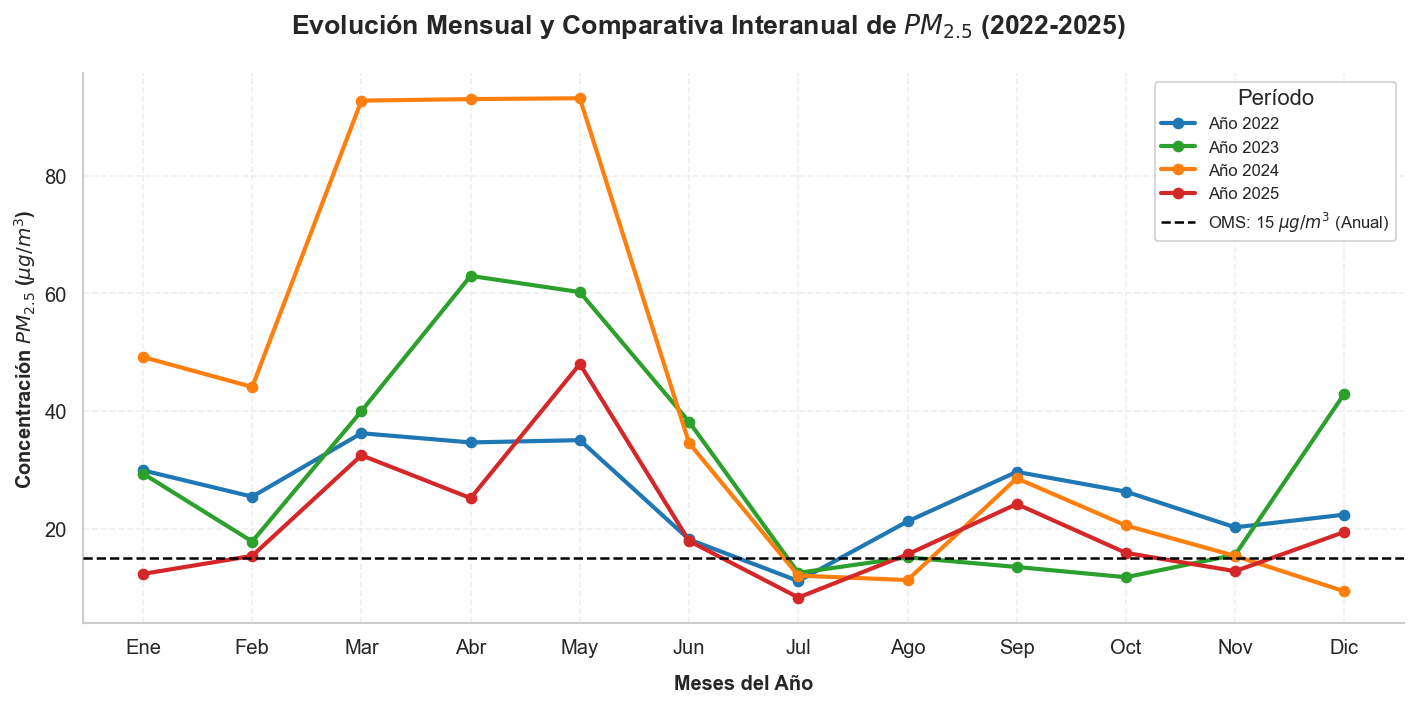

In [21]:
# 1. Asegurar la extracción de componentes temporales (si no lo has hecho ya)
df_merged['PERIOD'] = pd.to_datetime(df_merged['PERIOD'])
df_merged['ANIO'] = df_merged['PERIOD'].dt.year
df_merged['MES_NUM'] = df_merged['PERIOD'].dt.month

anios = [2022, 2023, 2024, 2025]
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Paleta de colores para diferenciar claramente cada año en la misma gráfica
colores = {
    2022: '#1f77b4',  # Azul
    2023: '#2ca02c',  # Verde
    2024: '#ff7f0e',  # Naranja
    2025: '#d62728'   # Rojo
}

# 2. Crear una única figura
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Evolución Mensual y Comparativa Interanual de $PM_{2.5}$ (2022-2025)',
             fontsize=16, fontweight='bold')

# 3. Iterar sobre cada año y graficar en el MISMO eje (ax)
for anio in anios:
    # Filtrar datos exclusivamente de ese año ordenados por mes
    df_anio = df_merged[df_merged['ANIO'] == anio].sort_values('MES_NUM')

    # Graficar la curva del año actual
    ax.plot(df_anio['MES_NUM'], df_anio['PM25_MEAN'],
            color=colores[anio], marker='o', markersize=6, linewidth=2.5,
            label=f'Año {anio}')

# Línea de referencia normativa (Guías OMS) en un color neutral para que resalte
ax.axhline(15, color='black', linestyle='--', linewidth=1.5, zorder=5,
           label='OMS: 15 $\mu g/m^3$ (Anual)')

# Formateo de etiquetas
ax.set_ylabel('Concentración $PM_{2.5}$ ($\mu g/m^3$)', fontsize=12, fontweight='bold')
ax.set_xlabel('Meses del Año', fontsize=12, fontweight='bold', labelpad=10)

# Configuración del eje X para que muestre los meses correctamente
ax.set_xticks(range(1, 13))
ax.set_xticklabels(nombres_meses)

# Ubicación de la leyenda
ax.legend(title='Período', fontsize=10, loc='upper right', framealpha=0.9, edgecolor='#cccccc')

# Estética y limpieza visual
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajuste fino y guardado
plt.tight_layout()
plt.savefig('./Output/pm25_superpuesto_interanual.png', dpi=150, bbox_inches='tight')
plt.show()

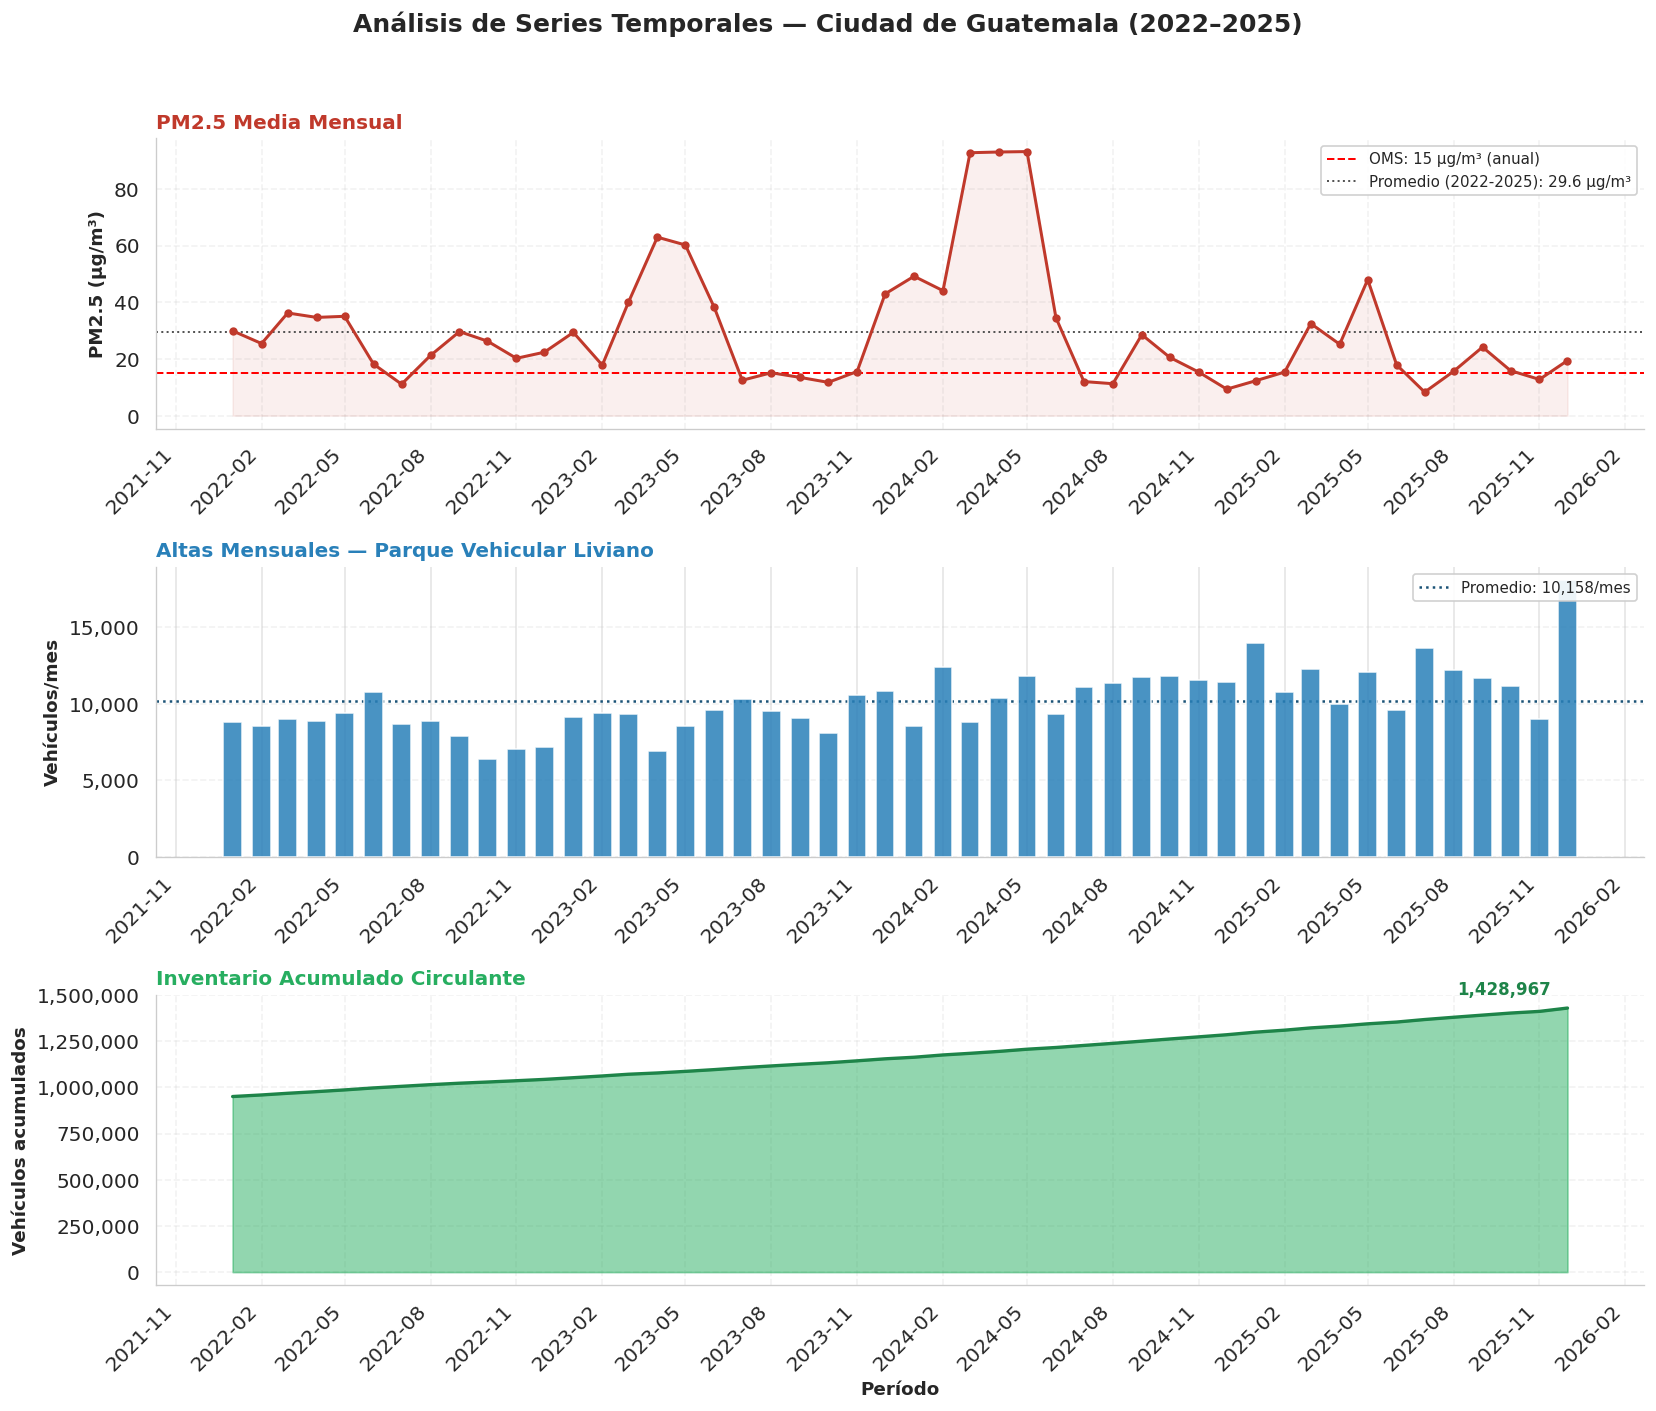

In [22]:

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
})

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True) # Se subió ligeramente la altura a 12 para dar espacio a las etiquetas rotadas
fig.suptitle('Análisis de Series Temporales — Ciudad de Guatemala (2022–2025)',
             fontsize=15, fontweight='bold', y=0.98)

# ---- Panel 1: PM2.5 ----
ax = axes[0]
ax.plot(df_merged['PERIOD'], df_merged['PM25_MEAN'],
        color='#c0392b', marker='o', markersize=4, linewidth=1.8, zorder=3)
ax.fill_between(df_merged['PERIOD'], df_merged['PM25_MEAN'],
                color='#c0392b', alpha=0.08, zorder=1)
ax.axhline(15, color='red', linestyle='--', linewidth=1.2, label='OMS: 15 μg/m³ (anual)')
#ax.axhline(25, color='red', linestyle='--', linewidth=1.2, label='OMS: 25 μg/m³ (24 h)')
prom = df_merged['PM25_MEAN'].mean()
ax.axhline(prom, color='#555555', linestyle=':', linewidth=1.2,
           label=f'Promedio (2022-2025): {prom:.1f} μg/m³')
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11, fontweight='bold')
ax.set_title('PM2.5 Media Mensual', fontsize=12, fontweight='bold', loc='left', color='#c0392b')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

# ---- Panel 2: Altas mensuales ----
ax = axes[1]
bars = ax.bar(df_merged['PERIOD'], df_merged['ALTAS_MENS'],
              color='#2980b9', alpha=0.85, width=20, zorder=3)
prom_altas = df_merged['ALTAS_MENS'].mean()
ax.axhline(prom_altas, color='#1a5276', linestyle=':', linewidth=1.5,
           label=f'Promedio: {prom_altas:,.0f}/mes')
ax.set_ylabel('Vehículos/mes', fontsize=11, fontweight='bold')
ax.set_title('Altas Mensuales — Parque Vehicular Liviano',
              fontsize=12, fontweight='bold', loc='left', color='#2980b9')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, axis='y', alpha=0.25, linestyle='--')

# ---- Panel 3: Acumulado ----
ax = axes[2]
ax.fill_between(df_merged['PERIOD'], df_merged['ACUMULADO'],
                alpha=0.5, color='#27ae60', zorder=1)
ax.plot(df_merged['PERIOD'], df_merged['ACUMULADO'],
        color='#1e8449', linewidth=2, zorder=3)
total = df_merged['ACUMULADO'].iloc[-1]
ax.annotate(f'{total:,.0f}',
            xy=(df_merged['PERIOD'].iloc[-1], total),
            xytext=(-10, 8), textcoords='offset points',
            fontsize=10, fontweight='bold', color='#1e8449', ha='right')
ax.set_ylabel('Vehículos acumulados', fontsize=11, fontweight='bold')
ax.set_title('Inventario Acumulado Circulante',
              fontsize=12, fontweight='bold', loc='left', color='#27ae60')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Período', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.25, linestyle='--')


# ---- MODIFICACIÓN CRÍTICA: Configuración del Eje X en TODOS los paneles ----
for a in axes:
    # 1. Forzar a que las etiquetas inferiores sigan siendo visibles a pesar del sharex=True
    a.tick_params(axis='x', labelbottom=True, rotation=45)

    # 2. Asignar el intervalo de 3 meses a cada gráfica individual de forma explícita
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 3. Alinear el texto rotado a la derecha para que coincida exactamente con la marca (tick)
    for label in a.get_xticklabels():
        label.set_horizontalalignment('right')

    # 4. Limpieza estética de bordes
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)


# Ajuste fino final manteniendo las proporciones
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('./Output/series_temporales_consolidadas.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:

df_merged.to_csv('./Data/df_merged_limpio.csv', index=False, encoding='utf-8')


In [24]:
df_merged.head(6)

,PERIOD,PM25_MEAN,ALTAS_MENS,ACUMULADO,ANIO,MES_NUM
0,2022-01-01,29.9052,8823,950203,2022,1
1,2022-02-01,25.4379,8520,958723,2022,2
2,2022-03-01,36.2192,9019,967742,2022,3
3,2022-04-01,34.6538,8897,976639,2022,4
4,2022-05-01,35.0429,9418,986057,2022,5
5,2022-06-01,18.1700,10737,996794,2022,6


In [25]:
# ── Delta multianual (mismo mes, año vs año, lag-12) ───────────────────────
# NOTA: este delta interanual es exploratorio. La correlación metodológicamente
# defendible (1ª diferencia + cointegración) se calcula en la celda siguiente.
df_d = df_merged.sort_values('PERIOD').copy()

df_d['D_PM25']     = df_d['PM25_MEAN'].diff(12)
df_d['D_ALTAS']    = df_d['ALTAS_MENS'].diff(12)
df_d['D_ACUMULADO']= df_d['ACUMULADO'].diff(12)

df_delta = df_d.dropna(subset=['D_PM25','D_ALTAS','D_ACUMULADO']).reset_index(drop=True)
print(f"Observaciones de delta (lag-12): {len(df_delta)}")
display(df_delta[['PERIOD','D_PM25','D_ALTAS','D_ACUMULADO']])

Observaciones de delta (lag-12): 36


,PERIOD,D_PM25,D_ALTAS,D_ACUMULADO
0,2023-01-01,-0.5407,314.0000,"101,855.0000"
1,2023-02-01,-7.6249,898.0000,"102,753.0000"
2,2023-03-01,3.7550,306.0000,"103,059.0000"
3,2023-04-01,28.3062,"-1,983.0000","101,076.0000"
4,2023-05-01,25.1604,-866.0000,"100,210.0000"
5,2023-06-01,19.9921,"-1,152.0000","99,058.0000"
6,2023-07-01,1.3871,"1,664.0000","100,722.0000"
7,2023-08-01,-6.1043,619.0000,"101,341.0000"
8,2023-09-01,-16.1633,"1,164.0000","102,505.0000"
9,2023-10-01,-14.5387,"1,700.0000","104,205.0000"


In [26]:
# ── Correlación : series DIFERENCIADAS + cointegración ──────────────
# Correlacionar PM2.5 (estacionaria, I(0)) contra ACUMULADO (no estacionario,
# I(1)) en NIVELES produce correlación espuria. Se corrige de dos formas:
from statsmodels.tsa.stattools import coint

df_c = df_merged.dropna(subset=['PM25_MEAN','ALTAS_MENS','ACUMULADO']).copy()

def corr_delta(x, y, label):
    rp, pp = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    return {'Relación': label, 'N': len(x),
            'Pearson r': rp, 'p (Pearson)': pp,
            'Spearman ρ': rs, 'p (Spearman)': ps}

# (A) Correlación sobre PRIMERA DIFERENCIA (ambas series estacionarias)
d_pm   = df_c['PM25_MEAN'].diff()
d_acum = df_c['ACUMULADO'].diff()
d_alta = df_c['ALTAS_MENS'].diff()
m = d_pm.notna() & d_acum.notna() & d_alta.notna()

res = pd.DataFrame([
    corr_delta(d_alta[m].values, d_pm[m].values, 'ΔAltas (flujo) vs ΔPM2.5'),
    corr_delta(d_acum[m].values, d_pm[m].values, 'ΔAcumulado (stock) vs ΔPM2.5'),
])
display(res.style
        .background_gradient(subset=['Pearson r','Spearman ρ'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Pearson r':'{:.4f}','p (Pearson)':'{:.4f}',
                 'Spearman ρ':'{:.4f}','p (Spearman)':'{:.4f}'})
        .set_caption('Correlación sobre series diferenciadas (estacionarias)'))

# (B) Cointegración Engle-Granger: ¿hay relación de equilibrio de largo plazo
#     entre el stock vehicular y PM2.5? (válida sobre niveles, a diferencia de
#     Pearson directo).
stat, pval, _ = coint(df_c['PM25_MEAN'], df_c['ACUMULADO'])
print(f"\nEngle-Granger (PM2.5 ~ ACUMULADO): estadístico={stat:.4f}  p={pval:.4f}")
if pval < 0.05:
    print("→ Series COINTEGRADAS: existe relación de largo plazo. Considerar un")
    print("  Modelo de Corrección de Error (ECM) como extensión.")
else:
    print("→ NO cointegradas: una correlación directa sobre niveles sería espuria.")
    print("  La asociación stock–PM2.5 a escala mensual no se sostiene.")

,Relación,N,Pearson r,p (Pearson),Spearman ρ,p (Spearman)
0,ΔAltas (flujo) vs ΔPM2.5,47,0.0067,0.9643,0.0071,0.9625
1,ΔAcumulado (stock) vs ΔPM2.5,47,0.0180,0.9045,-0.0173,0.9079



Engle-Granger (PM2.5 ~ ACUMULADO): estadístico=-3.5990  p=0.0246
→ Series COINTEGRADAS: existe relación de largo plazo. Considerar un
  Modelo de Corrección de Error (ECM) como extensión.


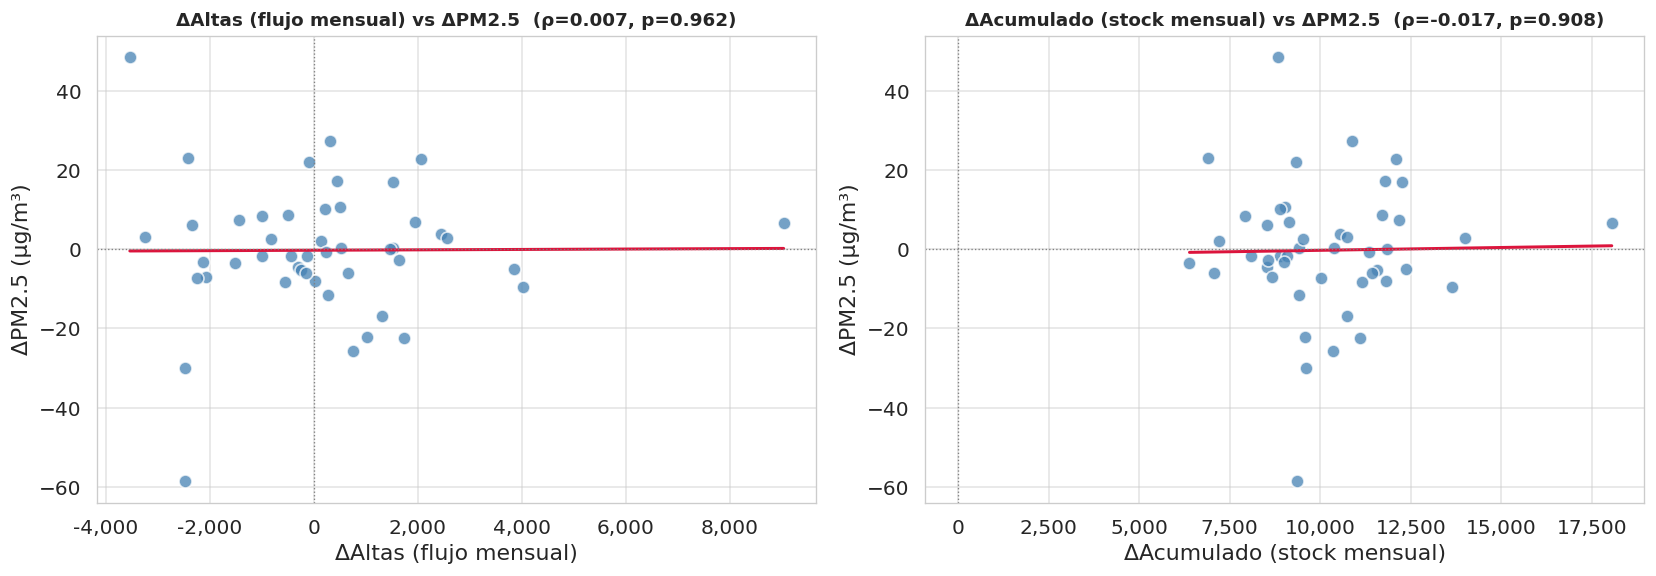

In [27]:
# ── Scatter de los deltas (primera diferencia) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pares = [(d_alta[m].values, 'Δ AAltas (flujo mensual)'),
         (d_acum[m].values, 'ΔAcumulado (stock mensual)')]
yv = d_pm[m].values
for ax, (xv, lab) in zip(axes, pares):
    rs, ps = spearmanr(xv, yv)
    ax.scatter(xv, yv, alpha=0.75, color='steelblue', edgecolors='white', s=60)
    mm, bb = np.polyfit(xv, yv, 1)
    xl = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xl, mm*xl + bb, color='crimson', linewidth=1.8)
    ax.axhline(0, color='gray', ls=':', lw=0.8); ax.axvline(0, color='gray', ls=':', lw=0.8)
    ax.set_title(f'{lab} vs ΔPM2.5  (ρ={rs:.3f}, p={ps:.3f})', fontweight='bold', fontsize=11)
    ax.set_xlabel(f'{lab}'); ax.set_ylabel('ΔPM2.5 (μg/m³)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.tight_layout()
plt.savefig('./Output/scatter_deltas_diferenciados.png', bbox_inches='tight', dpi=150)
plt.show()

## Fase 4: Modelado de Series Temporales

### 4.1 Prueba de Estacionariedad — Test ADF (Augmented Dickey-Fuller)

Un modelo ARIMA requiere que la serie sea estacionaria (media y varianza constantes en el tiempo). El test ADF contrasta la hipótesis nula H₀: la serie tiene raíz unitaria (no estacionaria).

In [28]:
def adf_report(serie, nombre):
    result = adfuller(serie.dropna(), autolag='AIC')
    print(f"\n{'='*55}")
    print(f" ADF Test — {nombre}")
    print(f"{'='*55}")
    print(f"  Estadístico ADF : {result[0]:.4f}")
    print(f"  p-valor         : {result[1]:.4f}")
    print(f"  Lags utilizados : {result[2]}")
    print(f"  Obs. usadas     : {result[3]}")
    for k, v in result[4].items():
        print(f"  Valor crítico {k}: {v:.4f}")
    conclusion = "ESTACIONARIA " if result[1] < 0.05 else "NO ESTACIONARIA ✗ → diferenciación requerida"
    print(f"  Conclusión      : {conclusion}")
    return result[1]

p_pm25     = adf_report(df_merged['PM25_MEAN'],  'PM2.5 Media Mensual')
p_altas    = adf_report(df_merged['ALTAS_MENS'], 'Altas Mensuales')
p_acumul   = adf_report(df_merged['ACUMULADO'],  'Acumulado Circulante')


 ADF Test — PM2.5 Media Mensual
  Estadístico ADF : -3.4864
  p-valor         : 0.0083
  Lags utilizados : 1
  Obs. usadas     : 46
  Valor crítico 1%: -3.5813
  Valor crítico 5%: -2.9268
  Valor crítico 10%: -2.6015
  Conclusión      : ESTACIONARIA 

 ADF Test — Altas Mensuales
  Estadístico ADF : -0.2869
  p-valor         : 0.9273
  Lags utilizados : 4
  Obs. usadas     : 43
  Valor crítico 1%: -3.5925
  Valor crítico 5%: -2.9315
  Valor crítico 10%: -2.6041
  Conclusión      : NO ESTACIONARIA ✗ → diferenciación requerida

 ADF Test — Acumulado Circulante
  Estadístico ADF : 5.1557
  p-valor         : 1.0000
  Lags utilizados : 1
  Obs. usadas     : 46
  Valor crítico 1%: -3.5813
  Valor crítico 5%: -2.9268
  Valor crítico 10%: -2.6015
  Conclusión      : NO ESTACIONARIA ✗ → diferenciación requerida


### 4.2 Gráficos ACF y PACF — PM2.5

La función de autocorrelación (ACF) y la autocorrelación parcial (PACF) guían la selección de los órdenes MA(q) y AR(p) del modelo ARIMA respectivamente.

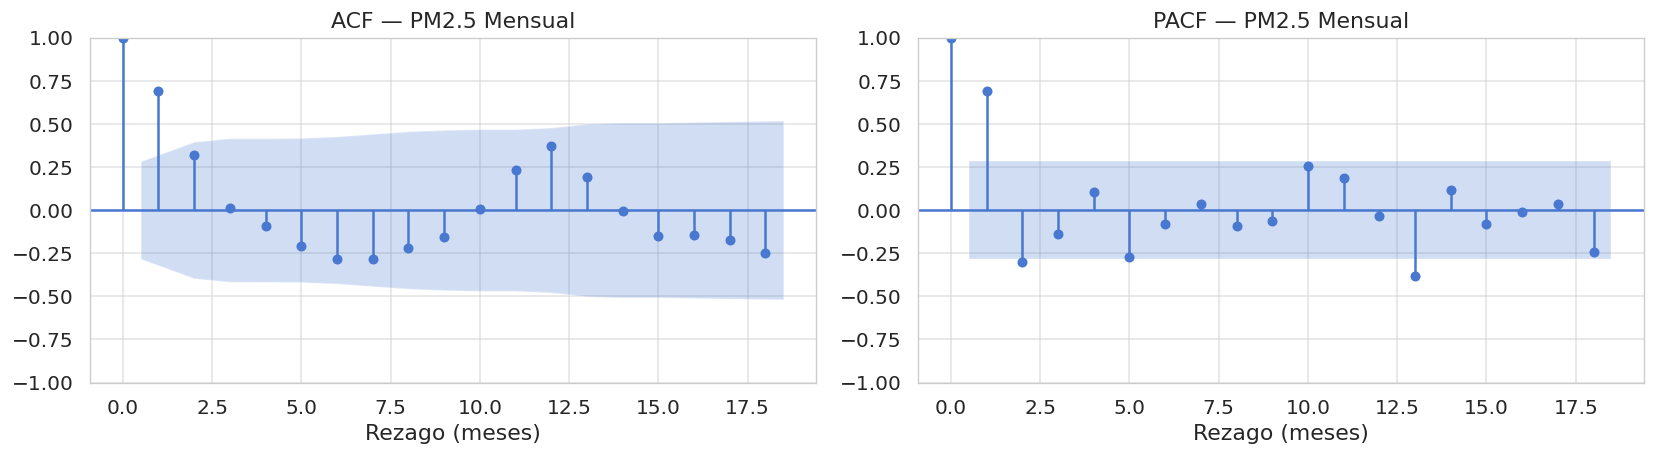

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( df_merged['PM25_MEAN'].dropna(), lags=18, ax=axes[0], title='ACF — PM2.5 Mensual')
plot_pacf(df_merged['PM25_MEAN'].dropna(), lags=18, ax=axes[1], title='PACF — PM2.5 Mensual', method='ywm')
axes[0].set_xlabel('Rezago (meses)'); axes[1].set_xlabel('Rezago (meses)')
plt.tight_layout()
plt.savefig('./Output/acf_pacf_pm25.png', bbox_inches='tight')
plt.show()

# Si la serie no es estacionaria, aplicar primera diferencia
if p_pm25 >= 0.05:
    df_merged['PM25_DIFF1'] = df_merged['PM25_MEAN'].diff()
    print("Serie diferenciada (d=1) generada.")
    adf_report(df_merged['PM25_DIFF1'].dropna(), 'PM2.5 Diferenciada (d=1)')

### 4.3 Primera Forma — Modelo ARIMA Univariante

El modelo ARIMA(p,d,q) captura la estructura temporal intrínseca del PM2.5 sin variables externas. Sirve como **línea base** para comparar con el modelo extendido SARIMAX.

- **p** (AR): número de rezagos autorregresivos
- **d** (I): grado de diferenciación para estacionariedad
- **q** (MA): número de términos de media móvil

In [30]:
# Selección automática del orden de diferenciación
d_order = 0 if p_pm25 < 0.05 else 1

# Ajuste ARIMA(1,d,1) como especificación parsimoniosamente justificada por ACF/PACF
arima_model = ARIMA(df_merged['PM25_MEAN'].dropna(), order=(1, d_order, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:              PM25_MEAN   No. Observations:                   48
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -197.139
Date:                Tue, 30 Jun 2026   AIC                            402.277
Time:                        09:16:44   BIC                            409.762
Sample:                             0   HQIC                           405.106
                                 - 48                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.4286      8.617      3.415      0.001      12.540      46.317
ar.L1          0.5646      0.139      4.056      0.000       0.292       0.837
ma.L1          0.2560      0.197      1.301      0.1

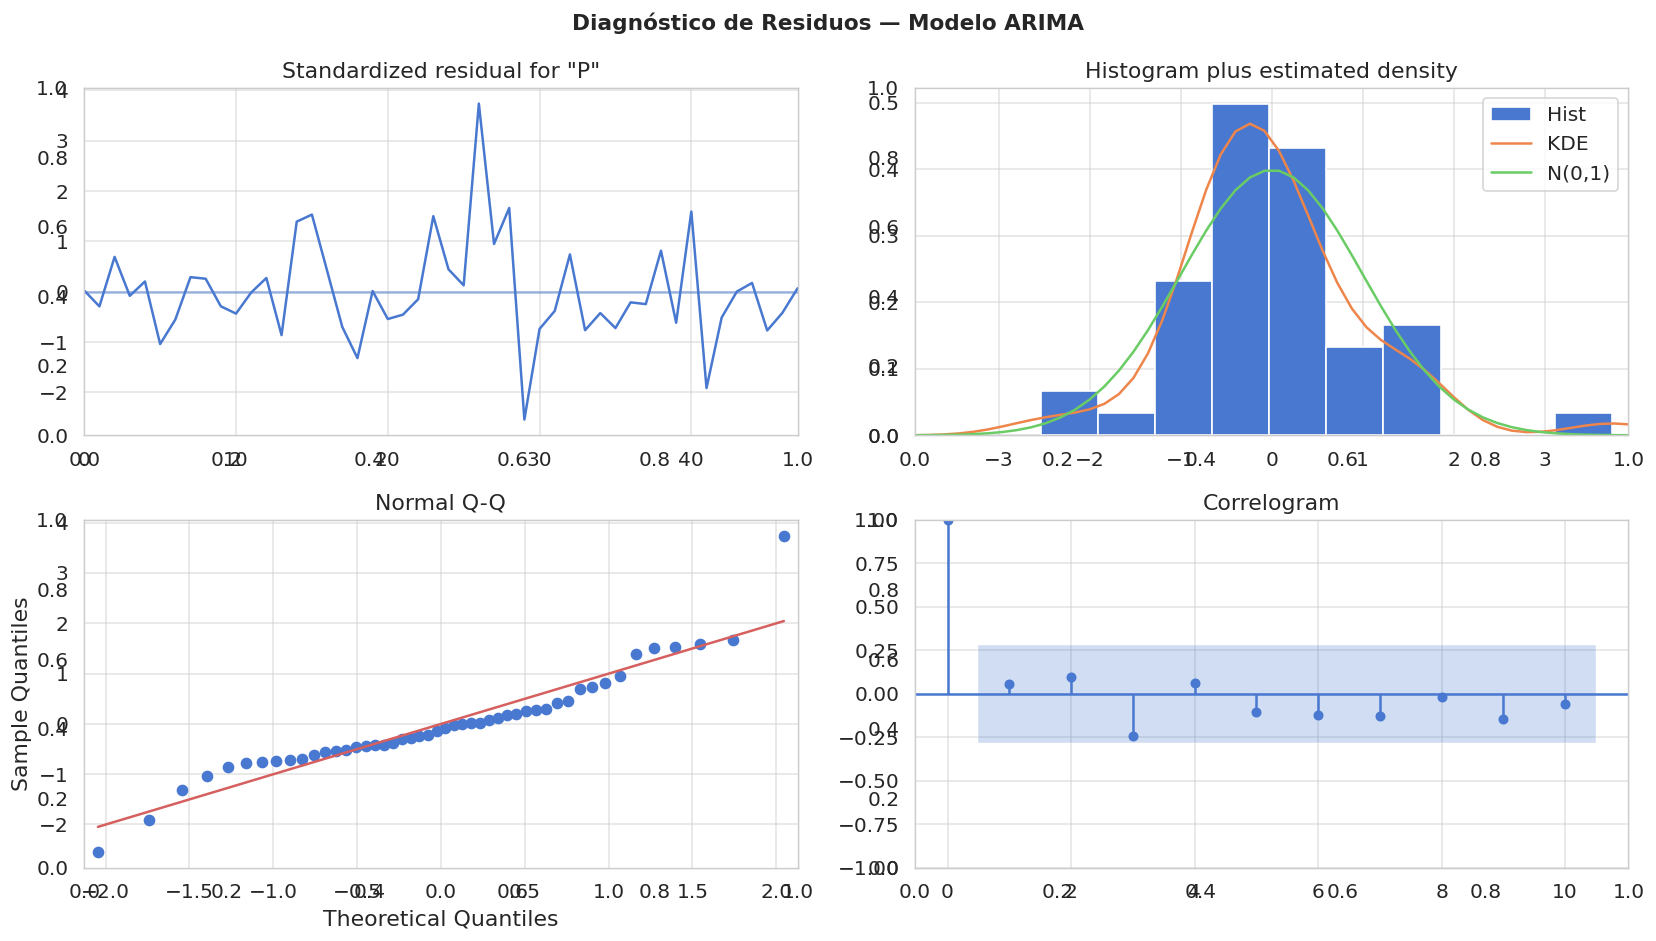

In [31]:
# Diagnóstico de residuos ARIMA
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
arima_result.plot_diagnostics(fig=fig)
fig.suptitle('Diagnóstico de Residuos — Modelo ARIMA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/diagnostico_arima.png', bbox_inches='tight')
plt.show()

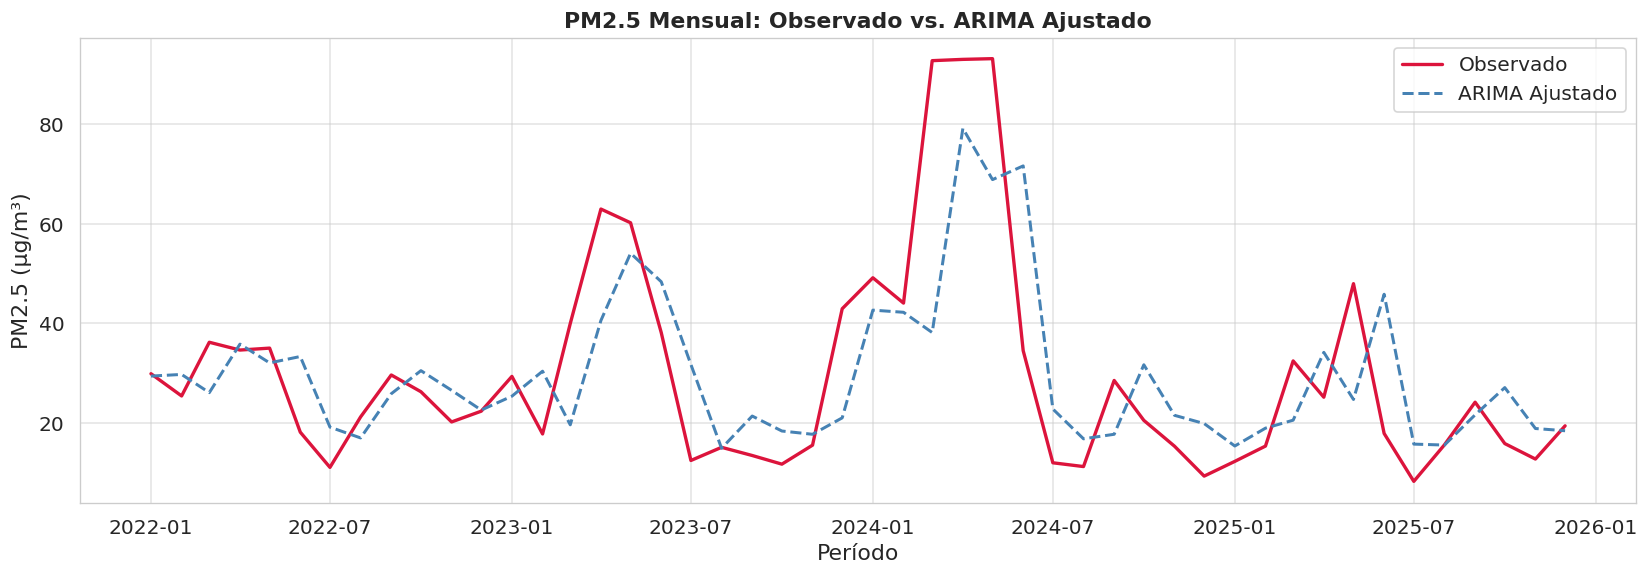

In [32]:
# Predicciones in-sample ARIMA
arima_pred = arima_result.fittedvalues
arima_pred.index = df_merged.index[:len(arima_pred)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_merged['PERIOD'], df_merged['PM25_MEAN'], label='Observado', color='crimson', linewidth=2)
ax.plot(df_merged['PERIOD'][:len(arima_pred)], arima_pred.values,
        label='ARIMA Ajustado', color='steelblue', linestyle='--', linewidth=1.8)
ax.set_title('PM2.5 Mensual: Observado vs. ARIMA Ajustado', fontweight='bold')
ax.set_xlabel('Período'); ax.set_ylabel('PM2.5 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('./Output/ajuste_arima.png', bbox_inches='tight')
plt.show()

### 4.4 Segunda Forma — Modelo SARIMAX con Variable Exógena

El modelo SARIMAX extiende el ARIMA incorporando:
- **Componente estacional (S):** captura patrones anuales (s=12 meses)
- **Variable exógena (exog):** el volumen de altas mensuales del parque vehicular liviano

La hipótesis es que un aumento en el número de vehículos que ingresan a circulación genera emisiones adicionales que elevan el PM2.5 en el mismo período mensual.

In [33]:
from sklearn.preprocessing import StandardScaler

# ── CORRECCIÓN DEL MODELO SARIMAX ──────────────────────────────────────────
# Problemas de la versión anterior:
#   1) exógena = ALTAS (flujo marginal ~8-13k/mes), NO la variable que
#      físicamente contamina. Lo correcto es el STOCK circulante (ACUMULADO).
#   2) ACUMULADO es no estacionario (ADF p=1.0) → se diferencia una vez.
#   3) seasonal_order=(1,0,1,12) con n~46 no es identificable → se reduce.
#   4) enforce_*=False llevaba el optimizador a una región degenerada
#      (std err = 0, z = inf, AIC ~1500). Se activan las restricciones.

# Dataset de modelado sin NaN y alineado temporalmente
df_model = df_merged.dropna(subset=['PM25_MEAN','ACUMULADO']).copy().reset_index(drop=True)
print(f"Observaciones para modelado SARIMAX: {len(df_model)}")

# Exógena = crecimiento mensual del parque circulante (stock diferenciado)
exog_raw = df_model['ACUMULADO'].diff().fillna(0).values.reshape(-1, 1)
scaler = StandardScaler()
exog_train = scaler.fit_transform(exog_raw)

sarimax_model = SARIMAX(
    df_model['PM25_MEAN'],
    exog=exog_train,
    order=(1, d_order, 1),
    seasonal_order=(1, 0, 0, 12),   # reducido: estimable con ~46 obs.
    enforce_stationarity=True,
    enforce_invertibility=True
)
sarimax_result = sarimax_model.fit(disp=False, maxiter=500)
print(sarimax_result.summary())

# ── Chequeo de identificabilidad ───────────────────────────────────────────
se = sarimax_result.bse
degenerado = bool((se == 0).any() or se.isna().any() or (sarimax_result.aic > 1000))
if degenerado:
    print("\nMODELO DEGENERADO / NO IDENTIFICABLE.")
    print("   No interpretar los coeficientes. Con n~46 el componente")
    print("   estacional puede no ser estimable: probar seasonal_order=(0,0,0,0)")
    print("   y reportar la limitación de tamaño muestral.")
else:
    coef_veh = sarimax_result.params['x1']
    print(f"\nModelo identificable. Coef. exógena (Δparque circulante, estandarizado): {coef_veh:.4f}")
    print("   Interpretación: efecto del crecimiento mensual del stock vehicular")
    print("   sobre PM2.5, controlando estructura temporal (AR/MA) y estacionalidad.")

Observaciones para modelado SARIMAX: 48
                                      SARIMAX Results                                      
Dep. Variable:                           PM25_MEAN   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -192.678
Date:                             Tue, 30 Jun 2026   AIC                            395.357
Time:                                     09:16:59   BIC                            404.713
Sample:                                          0   HQIC                           398.893
                                              - 48                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.2001      2.321     -0.086      0.931      -4.749

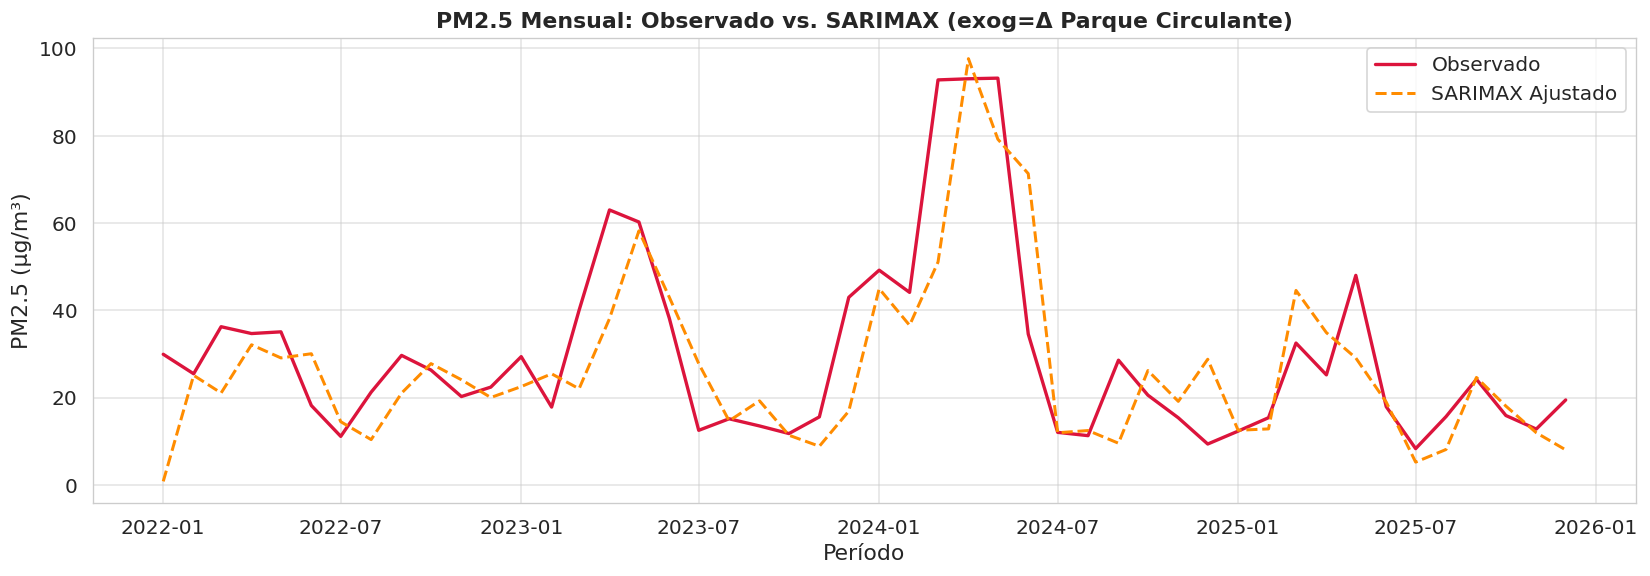

In [34]:
# Predicciones in-sample SARIMAX
sarimax_pred = sarimax_result.fittedvalues

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_model['PERIOD'], df_model['PM25_MEAN'], label='Observado', color='crimson', linewidth=2)
ax.plot(df_model['PERIOD'], sarimax_pred.values, label='SARIMAX Ajustado', color='darkorange',
        linestyle='--', linewidth=1.8)
ax.set_title('PM2.5 Mensual: Observado vs. SARIMAX (exog=Δ Parque Circulante)', fontweight='bold')
ax.set_xlabel('Período'); ax.set_ylabel('PM2.5 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('./Output/ajuste_sarimax.png', bbox_inches='tight')
plt.show()

## Fase 5: Evaluación de Modelos

### 5.1 Criterios de Información y Métricas de Error

Se utilizan cuatro criterios complementarios:
- **AIC** (Akaike): penaliza complejidad; menor es mejor.
- **BIC** (Bayesian): penaliza más fuertemente los parámetros adicionales.
- **RMSE** (Root Mean Squared Error): en unidades de μg/m³; penaliza errores grandes.
- **MAE** (Mean Absolute Error): en μg/m³; interpretación directa.

In [35]:
y_obs_arima   = df_merged['PM25_MEAN'].dropna().values
y_arima       = arima_result.fittedvalues.values[-len(y_obs_arima):]

y_obs_sarimax = df_model['PM25_MEAN'].values
y_sarimax     = sarimax_result.fittedvalues.values[-len(y_obs_sarimax):]

def metricas(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'RMSE (μg/m³)': rmse, 'MAE (μg/m³)': mae}

rows = [
    {'Modelo':'ARIMA(1,d,1)',
     'AIC': arima_result.aic, 'BIC': arima_result.bic,
     **metricas(y_obs_arima, y_arima)},
    {'Modelo':'SARIMAX(1,d,1)(1,0,0,12)+Δparque',
     'AIC': sarimax_result.aic, 'BIC': sarimax_result.bic,
     **metricas(y_obs_sarimax, y_sarimax)}
]
comp_df = pd.DataFrame(rows)
display(comp_df.style.format({'AIC':'{:.2f}','BIC':'{:.2f}','RMSE (μg/m³)':'{:.4f}','MAE (μg/m³)':'{:.4f}'})
        .highlight_min(color='lightgreen', subset=['AIC','BIC','RMSE (μg/m³)','MAE (μg/m³)']))

# ── Lectura honesta de la comparación ──────────────────────────────────────
mejor_aic = comp_df.loc[comp_df['AIC'].idxmin(), 'Modelo']
print(f"\nModelo con menor AIC: {mejor_aic}")
if sarimax_result.aic > arima_result.aic:
    print("→ El SARIMAX NO mejora al ARIMA. La variable vehicular no aporta")
    print("  poder explicativo adicional a escala mensual. Esto es un hallazgo")
    print("  válido y reportable, no un error.")
else:
    print("→ El SARIMAX mejora al ARIMA: la variable vehicular aporta información.")

,Modelo,AIC,BIC,RMSE (μg/m³),MAE (μg/m³)
0,"ARIMA(1,d,1)",402.28,409.76,14.5945,10.3180
1,"SARIMAX(1,d,1)(1,0,0,12)+Δparque",395.36,404.71,13.3316,9.2164



Modelo con menor AIC: SARIMAX(1,d,1)(1,0,0,12)+Δparque
→ El SARIMAX mejora al ARIMA: la variable vehicular aporta información.


### 5.2 Análisis de Residuos — Prueba de Ljung-Box y Normalidad


───────────────────────────────────────────────────────
 Diagnóstico de Residuos — ARIMA
───────────────────────────────────────────────────────
  Ljung-Box (H₀: no autocorrelación en residuos):


,Estadístico,p-valor
6,5.5016,0.4813
10,7.9880,0.6300
14,23.5053,0.0525


  Shapiro-Wilk       p=0.0043  → No normal ✗
  Jarque-Bera        p=0.0000  → No normal ✗


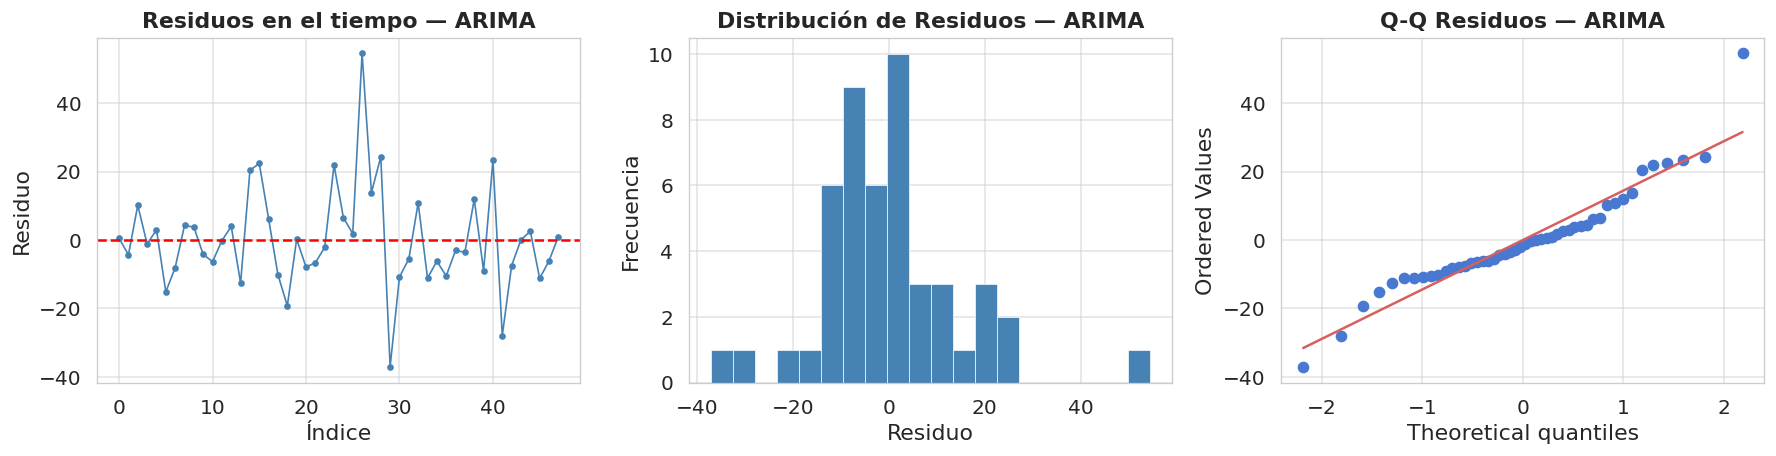


───────────────────────────────────────────────────────
 Diagnóstico de Residuos — SARIMAX
───────────────────────────────────────────────────────
  Ljung-Box (H₀: no autocorrelación en residuos):


,Estadístico,p-valor
6,4.5783,0.5989
10,5.0396,0.8885
14,6.9674,0.9360


  Shapiro-Wilk       p=0.0606  → Normal 
  Jarque-Bera        p=0.0427  → No normal ✗


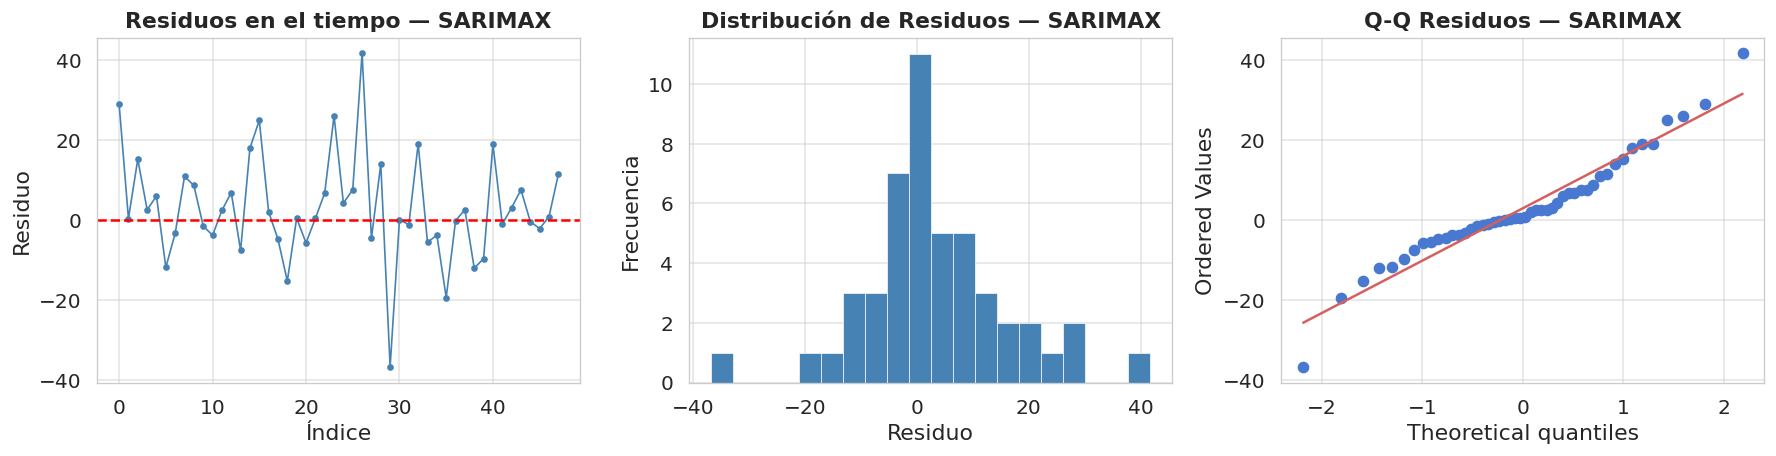

In [36]:
def residual_analysis(result, nombre):
    resid = result.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[6, 10, 14], return_df=True)
    _, p_sw = shapiro(resid)
    stat_jb, p_jb = jarque_bera(resid)
    print(f"\n{'─'*55}")
    print(f" Diagnóstico de Residuos — {nombre}")
    print(f"{'─'*55}")
    print("  Ljung-Box (H₀: no autocorrelación en residuos):")
    display(lb[['lb_stat','lb_pvalue']].rename(columns={'lb_stat':'Estadístico','lb_pvalue':'p-valor'}))
    print(f"  Shapiro-Wilk       p={p_sw:.4f}  → {'Normal ' if p_sw>0.05 else 'No normal ✗'}")
    print(f"  Jarque-Bera        p={p_jb:.4f}  → {'Normal ' if p_jb>0.05 else 'No normal ✗'}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(resid.values, marker='o', markersize=3, linewidth=1, color='steelblue')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'Residuos en el tiempo — {nombre}', fontweight='bold')
    axes[0].set_xlabel('Índice')
    axes[0].set_ylabel('Residuo')

    axes[1].hist(resid, bins=20, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[1].set_title(f'Distribución de Residuos — {nombre}', fontweight='bold')
    axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')

    stats.probplot(resid, dist='norm', plot=axes[2])
    axes[2].set_title(f'Q-Q Residuos — {nombre}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./Output/residuos_{nombre.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

residual_analysis(arima_result,   'ARIMA')
residual_analysis(sarimax_result, 'SARIMAX')

## Fase 6: Análisis de Correlación Avanzado

### Marco metodológico de correlaciones

> **Advertencia metodológica (corrección):** Las correlaciones de
> Pearson/Spearman entre el **acumulado en niveles** (serie I(1), no
> estacionaria) y el PM2.5 (serie I(0), estacionaria) son **espurias**: dos
> series con tendencia correlacionan artificialmente. Además, al rankear miles
> de columnas (p. ej. 13,817 líneas de vehículo) aparecen correlaciones altas
> por puro azar (problema de comparaciones múltiples).
>
> **Interpretación correcta:** los bloques siguientes se conservan como
> **exploración descriptiva** para identificar *segmentos candidatos*, NO como
> evidencia de asociación causal. La inferencia válida proviene del SARIMAX
> corregido y del test de cointegración (Fase 4 y celda 34). Cualquier segmento
> destacado aquí debe re-evaluarse diferenciando ambas series antes de afirmar
> una relación.

Se computan correlaciones de **Pearson** (relación lineal) y **Spearman**
(relación monotónica, robusta ante outliers) para cada segmentación.

**Bloque 1** — Variables basadas en el *Acumulado* del parque vehicular.
**Bloque 2** — Variables basadas únicamente en las *Altas* (nuevos ingresos por mes).

---
### Preparación de tablas pivote para correlaciones

In [37]:
# ─── Tabla pivot: ACUMULADO por MODELO_VEHICULO ─────────────────────────────
# Para el acumulado segmentado, se usa df_altas (registros dentro del período)
# y se calcula el cumsum por grupo de MODELO_VEHICULO mes a mes.

pivot_acum_modelo = (
    df_altas.groupby(['PERIOD_ALTA','MODELO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='MODELO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
    .cumsum()
)
pivot_acum_modelo.index = pd.to_datetime(pivot_acum_modelo.index)
pivot_acum_modelo = pivot_acum_modelo.sort_index()

# ─── Tabla pivot: ACUMULADO por TIPO_VEHICULO ────────────────────────────────
pivot_acum_tipo = (
    df_altas.groupby(['PERIOD_ALTA','TIPO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='TIPO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
    .cumsum()
)
pivot_acum_tipo.index = pd.to_datetime(pivot_acum_tipo.index)
pivot_acum_tipo = pivot_acum_tipo.sort_index()

# ─── Tabla pivot: ACUMULADO por LINEA_VEHICULO ───────────────────────────────
pivot_acum_linea = (
    df_altas.groupby(['PERIOD_ALTA','LINEA_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='LINEA_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
    .cumsum()
)
pivot_acum_linea.index = pd.to_datetime(pivot_acum_linea.index)
pivot_acum_linea = pivot_acum_linea.sort_index()

# ─── Tabla pivot: ALTAS por MODELO_VEHICULO ──────────────────────────────────
pivot_alta_modelo = (
    df_altas.groupby(['PERIOD_ALTA','MODELO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='MODELO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
)
pivot_alta_modelo.index = pd.to_datetime(pivot_alta_modelo.index)
pivot_alta_modelo = pivot_alta_modelo.sort_index()

# ─── Tabla pivot: ALTAS por TIPO_VEHICULO ────────────────────────────────────
pivot_alta_tipo = (
    df_altas.groupby(['PERIOD_ALTA','TIPO_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='TIPO_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
)
pivot_alta_tipo.index = pd.to_datetime(pivot_alta_tipo.index)
pivot_alta_tipo = pivot_alta_tipo.sort_index()

# ─── Tabla pivot: ALTAS por LINEA_VEHICULO ───────────────────────────────────
pivot_alta_linea = (
    df_altas.groupby(['PERIOD_ALTA','LINEA_VEHICULO'])['CANTIDAD']
    .sum()
    .reset_index()
    .pivot_table(index='PERIOD_ALTA', columns='LINEA_VEHICULO', values='CANTIDAD', aggfunc='sum', fill_value=0)
)
pivot_alta_linea.index = pd.to_datetime(pivot_alta_linea.index)
pivot_alta_linea = pivot_alta_linea.sort_index()

# Serie PM2.5 indexada para join
pm_idx = df_merged.set_index('PERIOD')['PM25_MEAN']

print("Pivotes construidos:")
print(f"  acum_modelo : {pivot_acum_modelo.shape}  |  acum_tipo : {pivot_acum_tipo.shape}")
print(f"  acum_linea  : {pivot_acum_linea.shape}")
print(f"  alta_modelo : {pivot_alta_modelo.shape}  |  alta_tipo : {pivot_alta_tipo.shape}")
print(f"  alta_linea  : {pivot_alta_linea.shape}")

Pivotes construidos:
  acum_modelo : (48, 47)  |  acum_tipo : (48, 17)
  acum_linea  : (48, 13814)
  alta_modelo : (48, 47)  |  alta_tipo : (48, 17)
  alta_linea  : (48, 13814)


In [38]:
def correlacion_segmentada(pivot, pm_serie, top_n=15, metodo='pearson'):
    """Calcula correlaciones entre cada columna del pivot y la serie de PM2.5."""
    df_join = pivot.join(pm_serie, how='inner')
    resultados = []
    for col in pivot.columns:
        x = df_join[col].values
        y = df_join['PM25_MEAN'].values
        mask_v = (~np.isnan(x)) & (~np.isnan(y)) & (np.std(x) > 0)
        if mask_v.sum() < 5:
            continue
        if metodo == 'pearson':
            r, p = pearsonr(x[mask_v], y[mask_v])
        else:
            r, p = spearmanr(x[mask_v], y[mask_v])
        resultados.append({'Segmento': col, 'Correlación': r, 'p-valor': p,
                           'Significativa': 'Sí' if p < 0.05 else 'No',
                           'Obs': mask_v.sum()})
    res_df = (pd.DataFrame(resultados)
              .sort_values('Correlación', key=abs, ascending=False)
              .reset_index(drop=True))
    return res_df.head(top_n)

print("Función de correlación segmentada definida.")

Función de correlación segmentada definida.


---
### Bloque 1: Correlaciones con el ACUMULADO del parque vehicular

#### 1.1 Acumulado por MODELO_VEHICULO (año de fabricación) vs. PM2.5

In [58]:
corr_acum_modelo = correlacion_segmentada(pivot_acum_modelo, pm_idx, top_n=10, metodo='spearman')
display(corr_acum_modelo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-10: Correlación Spearman — Acumulado por Modelo de Fabricación vs. PM2.5'))



,Segmento,Correlación,p-valor,Significativa,Obs
0,2026,-0.2986,0.0392,Sí,48
1,2025,-0.2794,0.0544,No,48
2,1982,-0.2752,0.0584,No,48
3,1985,-0.2680,0.0655,No,48
4,1988,-0.2665,0.0671,No,48
5,1993,-0.2654,0.0683,No,48
6,1990,-0.2645,0.0693,No,48
7,1989,-0.2642,0.0696,No,48
8,1980 o menor,-0.2641,0.0697,No,48
9,1991,-0.2641,0.0697,No,48


Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))  # adjust size
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=corr_acum_modelo.values,
                 colLabels=corr_acum_modelo.columns,
                 rowLabels=corr_acum_modelo.index,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)  # adjust scaling
plt.savefig('Output/tabla_sin_color.png', dpi=300, bbox_inches='tight')
plt.close()

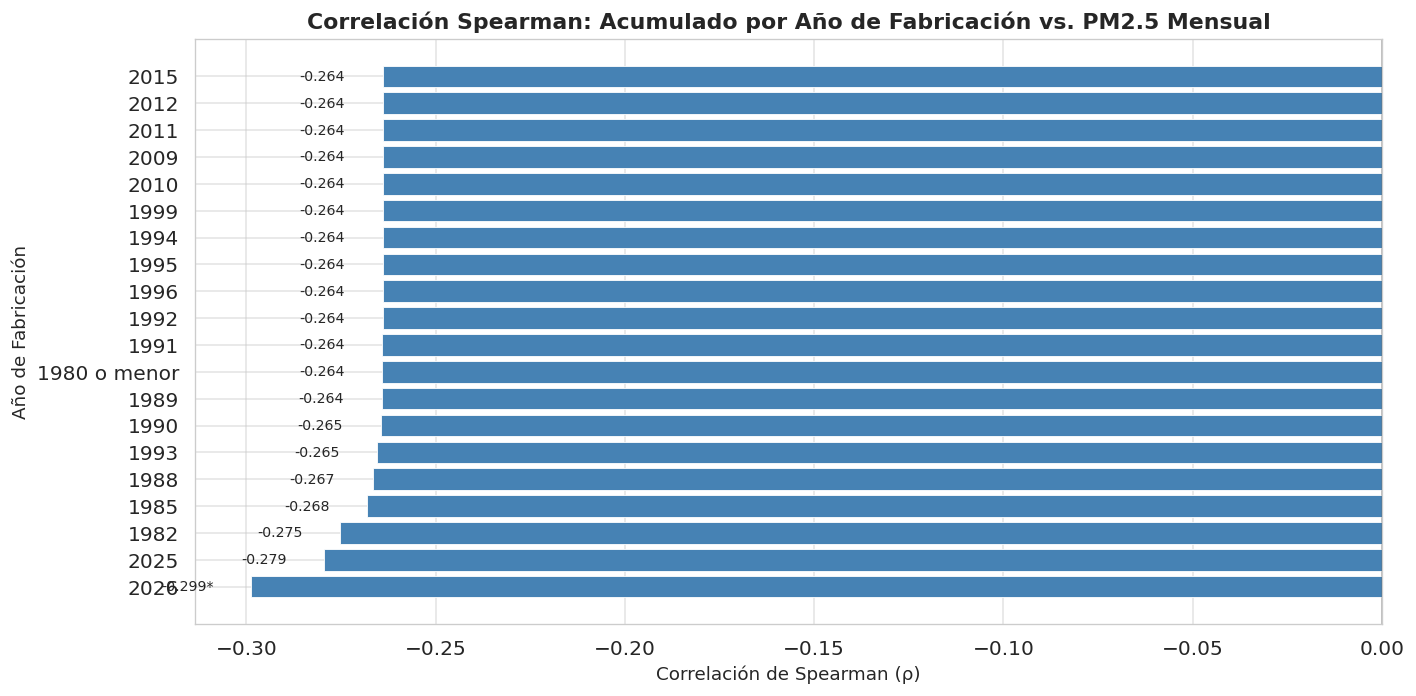

* = p < 0.05


In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['crimson' if v > 0 else 'steelblue' for v in corr_acum_modelo['Correlación']]
bars = ax.barh(corr_acum_modelo['Segmento'].astype(str), corr_acum_modelo['Correlación'],
               color=colores, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman (ρ)', fontsize=11)
ax.set_ylabel('Año de Fabricación', fontsize=11)
ax.set_title('Correlación Spearman: Acumulado por Año de Fabricación vs. PM2.5 Mensual', fontweight='bold')

for bar, (_, row) in zip(bars, corr_acum_modelo.iterrows()):
    sig = '*' if row['Significativa'] == 'Sí' else ''
    ax.text(bar.get_width() + 0.01 if bar.get_width() >= 0 else bar.get_width() - 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{row['Correlación']:.3f}{sig}", va='center', ha='left' if bar.get_width() >= 0 else 'right',
            fontsize=8.5)
plt.tight_layout()
plt.savefig('./Output/corr_acum_modelo.png', bbox_inches='tight')
plt.show()
print("* = p < 0.05")

#### 1.2 Acumulado por TIPO_VEHICULO vs. PM2.5

In [41]:
corr_acum_tipo = correlacion_segmentada(pivot_acum_tipo, pm_idx, top_n=20, metodo='spearman')
display(corr_acum_tipo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Correlación Spearman — Acumulado por Tipo de Vehículo vs. PM2.5'))



,Segmento,Correlación,p-valor,Significativa,Obs
0,CAMIONETA AGRICOLA,-0.2644,0.0694,No,48
1,TRIMOTO,-0.2640,0.0698,No,48
2,AUTOMOVIL,-0.2640,0.0698,No,48
3,CAMIONETA,-0.2640,0.0698,No,48
4,CAMIONETA SPORT,-0.2640,0.0698,No,48
5,CAMIONETILLA,-0.2640,0.0698,No,48
6,CUATRIMOTO,-0.2640,0.0698,No,48
7,JEEP,-0.2640,0.0698,No,48
8,MICROBUS,-0.2640,0.0698,No,48
9,VEHICULO RUSTICO,-0.2640,0.0698,No,48


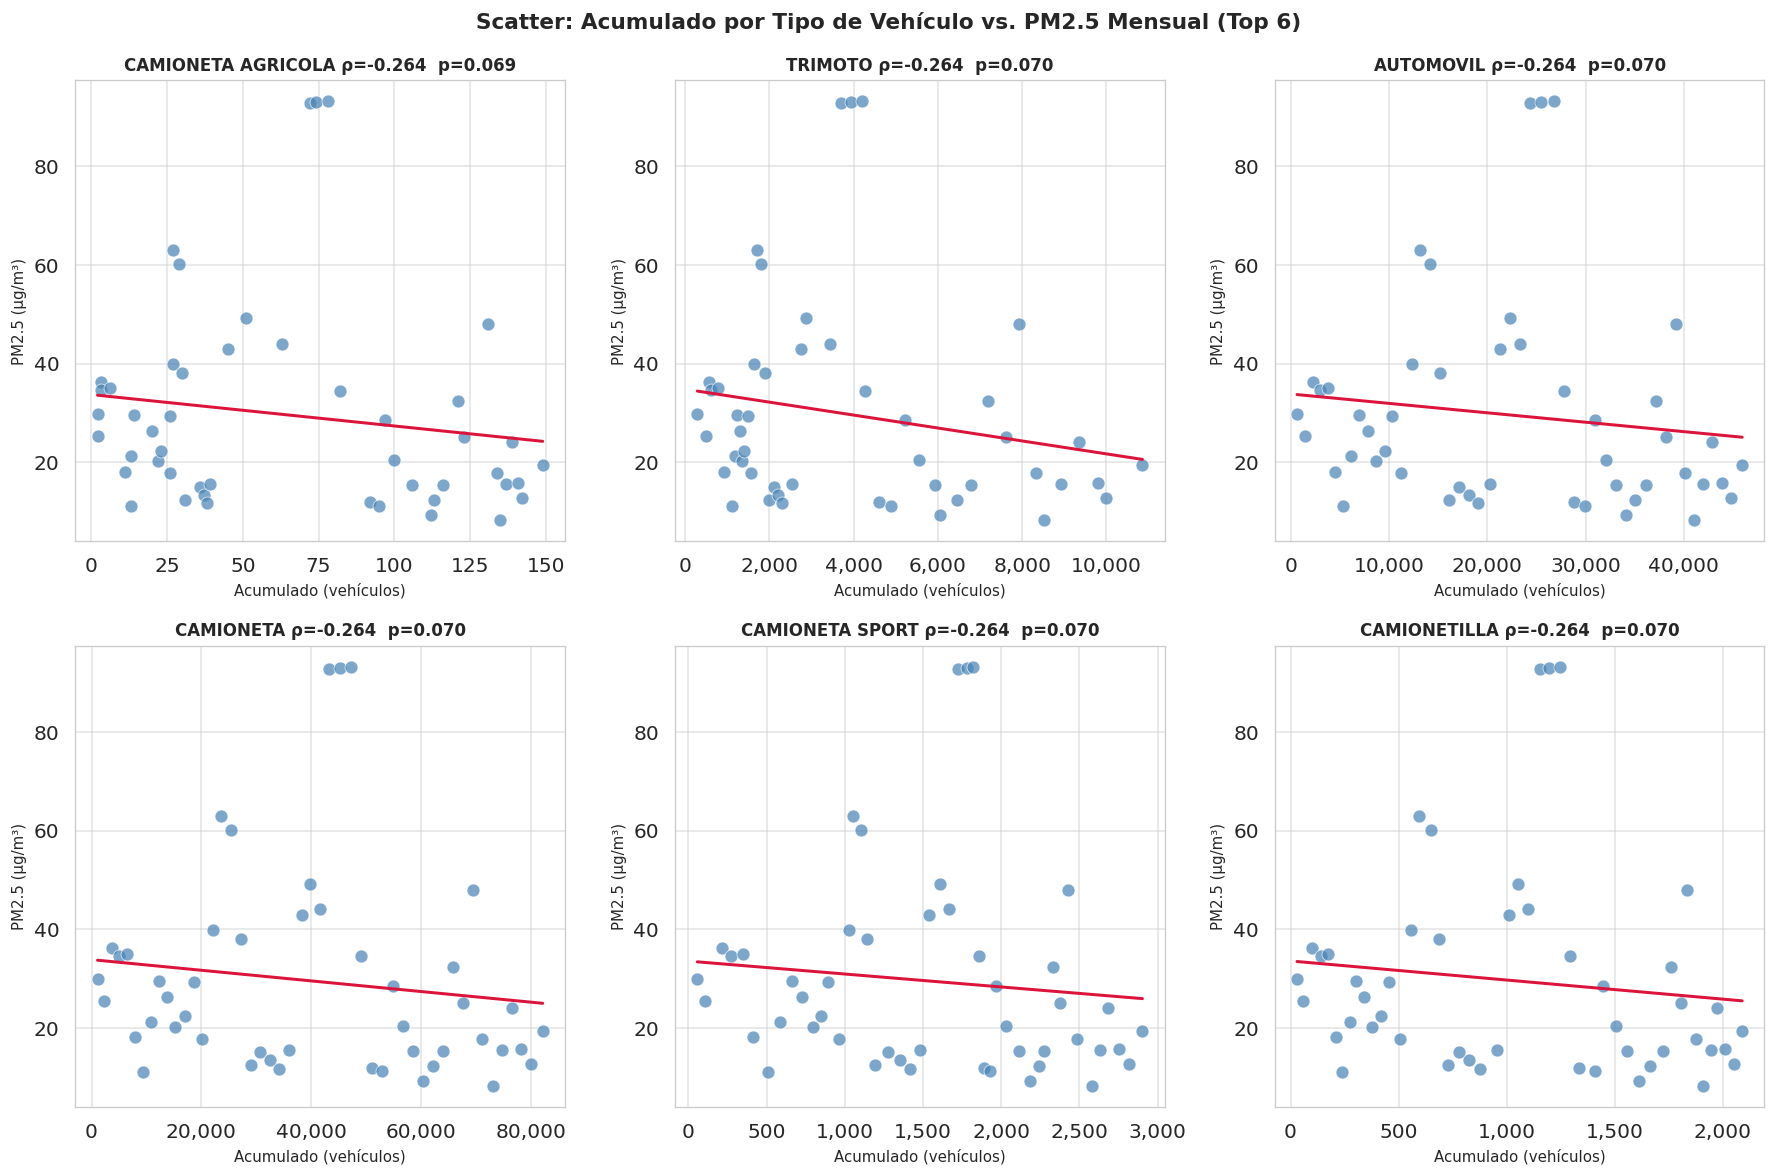

In [42]:
# Scatter plots por tipo de vehículo (top 6)
top_tipos = corr_acum_tipo.head(6)['Segmento'].tolist()
df_join_tipo = pivot_acum_tipo.join(pm_idx, how='inner')

n_cols = 3
n_rows = int(np.ceil(len(top_tipos)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, tipo in enumerate(top_tipos):
    if tipo not in df_join_tipo.columns:
        continue
    x = df_join_tipo[tipo].values
    y = df_join_tipo['PM25_MEAN'].values
    r, p = spearmanr(x, y)
    axes[i].scatter(x, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.5, s=60)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='crimson', linewidth=1.8)
    axes[i].set_title(f'{tipo} ρ={r:.3f}  p={p:.3f}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Acumulado (vehículos)', fontsize=9)
    axes[i].set_ylabel('PM2.5 (μg/m³)', fontsize=9)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

for j in range(len(top_tipos), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatter: Acumulado por Tipo de Vehículo vs. PM2.5 Mensual (Top 6)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/scatter_acum_tipo.png', bbox_inches='tight')
plt.show()

#### 1.3 Acumulado por LINEA_VEHICULO vs. PM2.5

In [57]:
corr_acum_linea = correlacion_segmentada(pivot_acum_linea, pm_idx, top_n=50, metodo='spearman')
display(corr_acum_linea.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-25: Correlación Spearman — Acumulado por Línea de Vehículo vs. PM2.5'))



,Segmento,Correlación,p-valor,Significativa,Obs
0,S10 LS 2WD,-0.4475,0.0014,Sí,48
1,CX-30 S AWD,-0.4434,0.0016,Sí,48
2,KONA LIMITED 2WD,-0.4434,0.0016,Sí,48
3,SANTA FE GLS 4WD,-0.4411,0.0017,Sí,48
4,GLADIATOR 4X4,-0.4411,0.0017,Sí,48
5,DLX 2WD,-0.4398,0.0018,Sí,48
6,SANTA FE LIMITED,-0.4382,0.0018,Sí,48
7,CITY EXPRESS LS,-0.4382,0.0018,Sí,48
8,ZR900FP,-0.4380,0.0018,Sí,48
9,1.25 FACTORY REPLICA,-0.4380,0.0018,Sí,48


Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

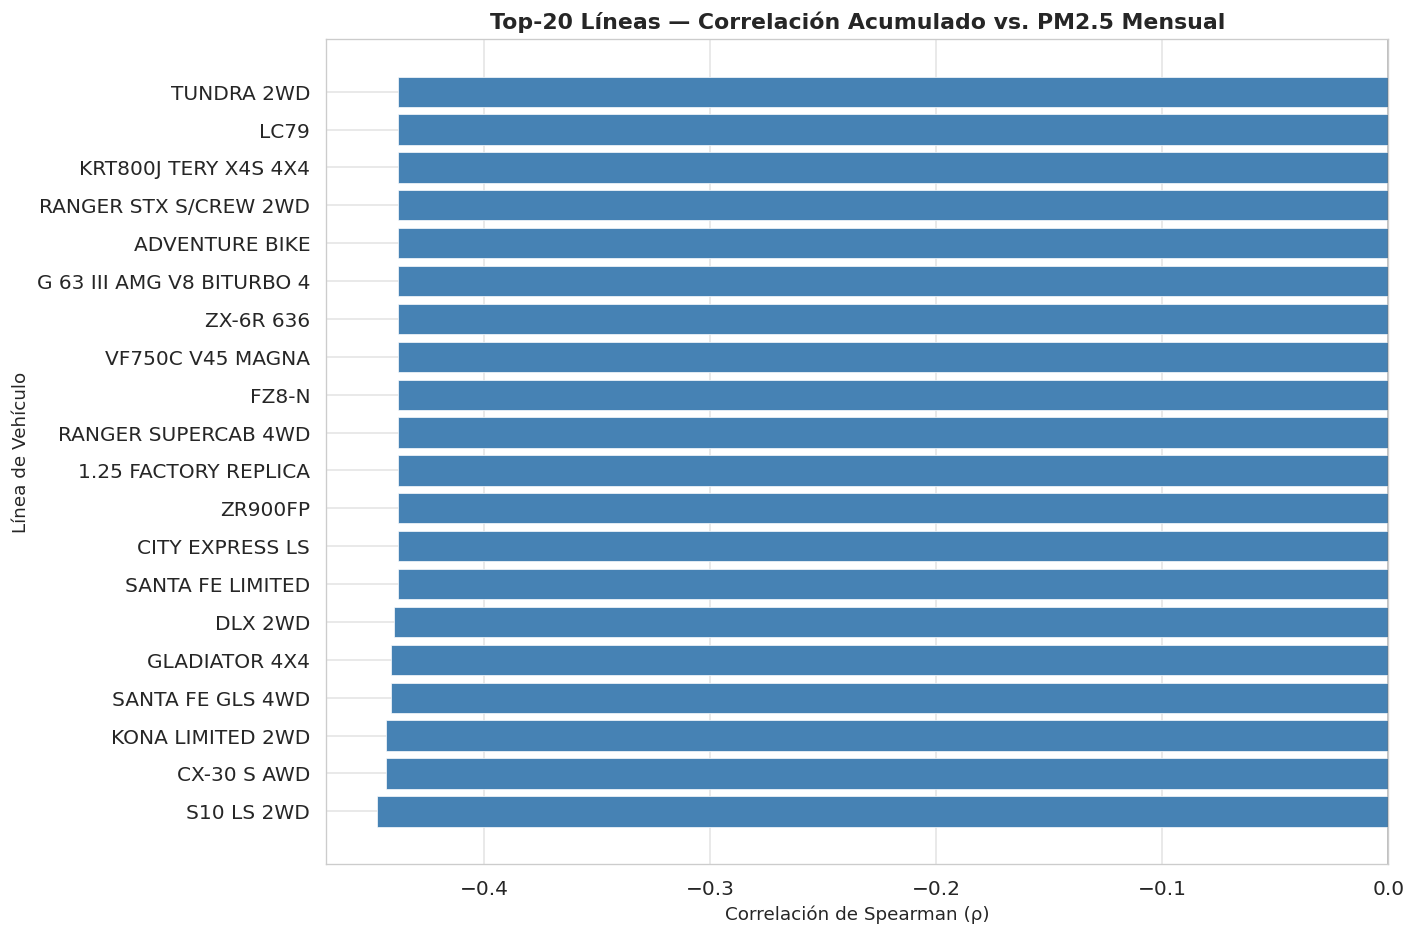

In [44]:
fig, ax = plt.subplots(figsize=(12, 8))
top20 = corr_acum_linea.head(20)
colores = ['crimson' if v > 0 else 'steelblue' for v in top20['Correlación']]
ax.barh(top20['Segmento'], top20['Correlación'], color=colores, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman (ρ)', fontsize=11)
ax.set_ylabel('Línea de Vehículo', fontsize=11)
ax.set_title('Top-20 Líneas — Correlación Acumulado vs. PM2.5 Mensual', fontweight='bold')
plt.tight_layout()
plt.savefig('./Output/corr_acum_linea.png', bbox_inches='tight')
plt.show()

---
### Bloque 2: Correlaciones con las ALTAS del parque vehicular

#### 2.1 Altas por MODELO_VEHICULO (año de fabricación) vs. PM2.5

In [45]:
corr_alta_modelo = correlacion_segmentada(pivot_alta_modelo, pm_idx, top_n=20, metodo='pearson')
display(corr_alta_modelo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-20: Correlación Pearson — Altas por Año de Fabricación vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,2024,0.3999,0.0049,Sí,48
1,1982,-0.3536,0.0137,Sí,48
2,1980 o menor,-0.3281,0.0228,Sí,48
3,1991,-0.3176,0.0278,Sí,48
4,2011,0.2984,0.0394,Sí,48
5,1987,0.2968,0.0405,Sí,48
6,1996,0.2902,0.0454,Sí,48
7,2010,0.2894,0.0460,Sí,48
8,2013,0.2716,0.0618,No,48
9,1990,-0.2591,0.0753,No,48


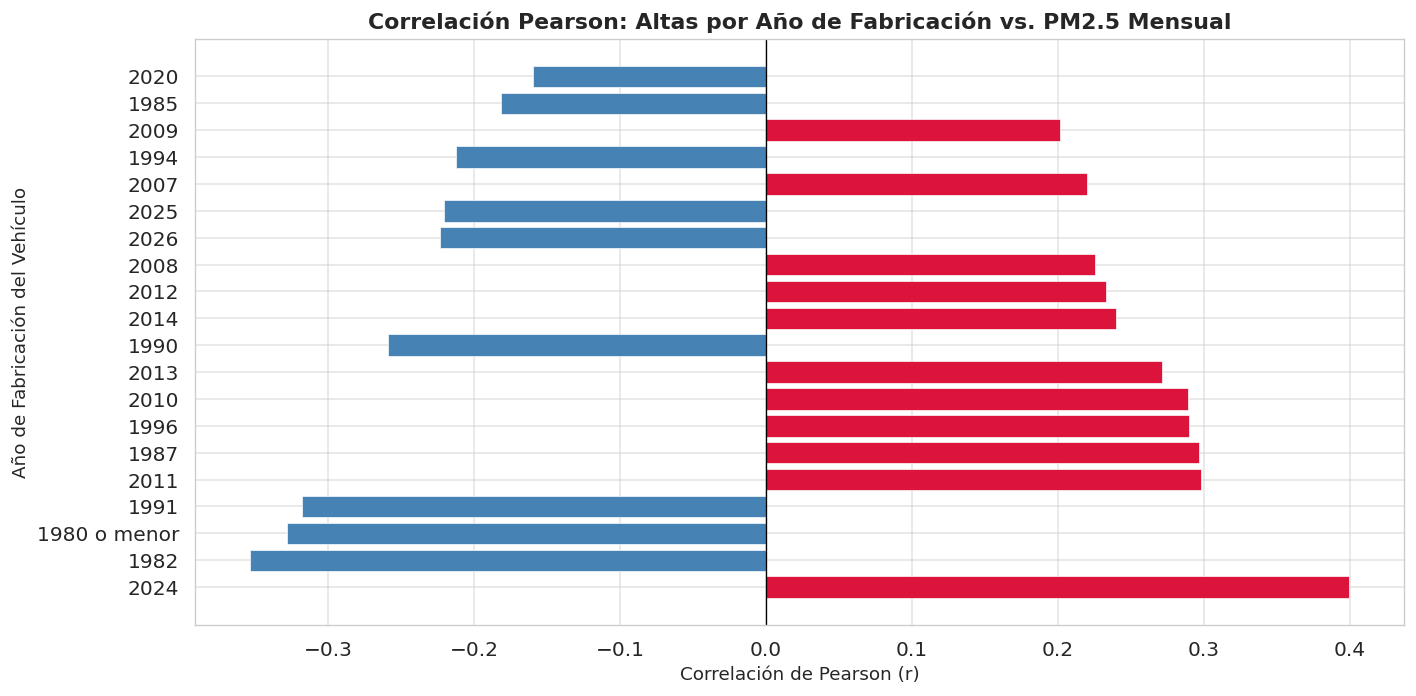

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['crimson' if v > 0 else 'steelblue' for v in corr_alta_modelo['Correlación']]
ax.barh(corr_alta_modelo['Segmento'].astype(str), corr_alta_modelo['Correlación'],
        color=colores, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson (r)', fontsize=11)
ax.set_ylabel('Año de Fabricación del Vehículo', fontsize=11)
ax.set_title('Correlación Pearson: Altas por Año de Fabricación vs. PM2.5 Mensual', fontweight='bold')
plt.tight_layout()
plt.savefig('./Output/corr_alta_modelo.png', bbox_inches='tight')
plt.show()

#### 2.2 Altas por TIPO_VEHICULO vs. PM2.5

In [47]:
corr_alta_tipo = correlacion_segmentada(pivot_alta_tipo, pm_idx, top_n=20, metodo='pearson')
display(corr_alta_tipo.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Correlación Pearson — Altas por Tipo de Vehículo vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,PANEL,-0.3351,0.0199,Sí,48
1,CAMIONETA SPORT,-0.2679,0.0656,No,48
2,AUTOMOVIL,0.2339,0.1096,No,48
3,CAMIONETA AGRICOLA,0.2087,0.1545,No,48
4,PICK UP,-0.1973,0.1790,No,48
5,MOTO,-0.1812,0.2178,No,48
6,CARRO PARA GOLF,-0.1475,0.3171,No,48
7,VEHICULO RUSTICO,0.1340,0.3638,No,48
8,JEEP,-0.1248,0.3980,No,48
9,CAMIONETA,0.0927,0.5307,No,48


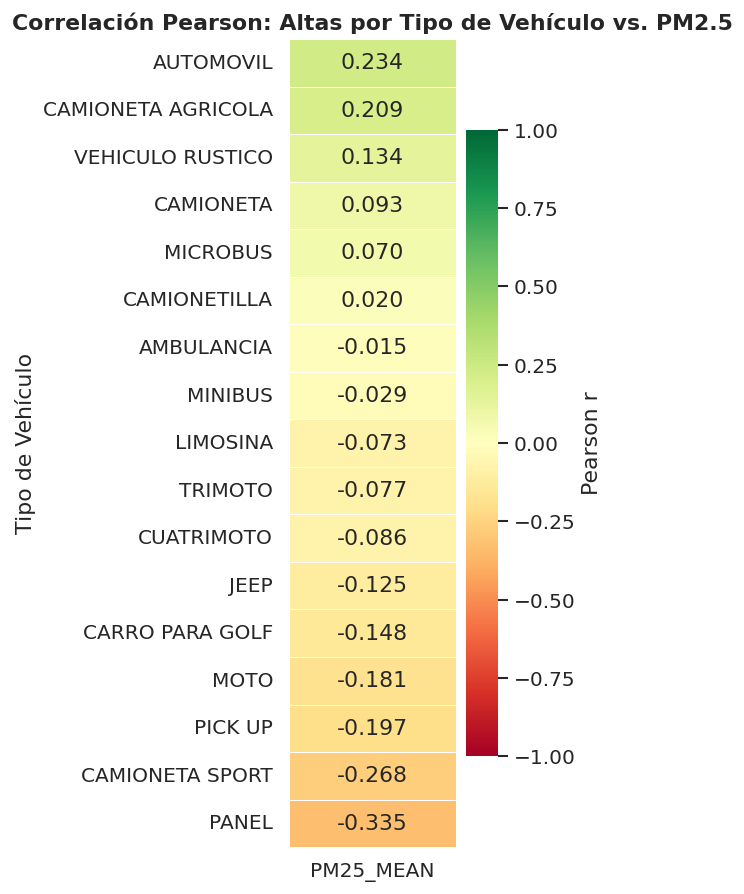

In [48]:
# Heatmap de correlación cruzada entre tipos de vehículo y PM2.5
df_join_alta_tipo = pivot_alta_tipo.join(pm_idx, how='inner')
corr_matrix = df_join_alta_tipo.corr(method='pearson')
pm_row = corr_matrix[['PM25_MEAN']].drop('PM25_MEAN').sort_values('PM25_MEAN', ascending=False)

fig, ax = plt.subplots(figsize=(5, max(4, len(pm_row)*0.45)))
sns.heatmap(pm_row, annot=True, fmt='.3f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlación Pearson: Altas por Tipo de Vehículo vs. PM2.5',  fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Tipo de Vehículo')
plt.tight_layout()
plt.savefig('./Output/heatmap_alta_tipo_pm25.png', bbox_inches='tight')
plt.show()

#### 2.3 Altas por LINEA_VEHICULO vs. PM2.5

In [49]:
corr_alta_linea = correlacion_segmentada(pivot_alta_linea, pm_idx, top_n=25, metodo='pearson')
display(corr_alta_linea.style
        .background_gradient(subset=['Correlación'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Correlación':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Top-25: Correlación Pearson — Altas por Línea de Vehículo vs. PM2.5'))

,Segmento,Correlación,p-valor,Significativa,Obs
0,SANTA FE SEL 2WD,0.6480,0.0000,Sí,48
1,S40 2.4I,0.6343,0.0000,Sí,48
2,ECLIPSE CROSS SE AWC,0.6343,0.0000,Sí,48
3,C-HR LE 4X2,0.6330,0.0000,Sí,48
4,SKYLINE,0.6330,0.0000,Sí,48
5,190 SCRAMBLER,0.5976,0.0000,Sí,48
6,R 1250 GS ADVENTURE,0.5917,0.0000,Sí,48
7,MIRAGE LIMITED EDITION,0.5878,0.0000,Sí,48
8,ENZZO 180,0.5699,0.0000,Sí,48
9,TACOMA XTRACAB SR5 4X4,0.5617,0.0000,Sí,48


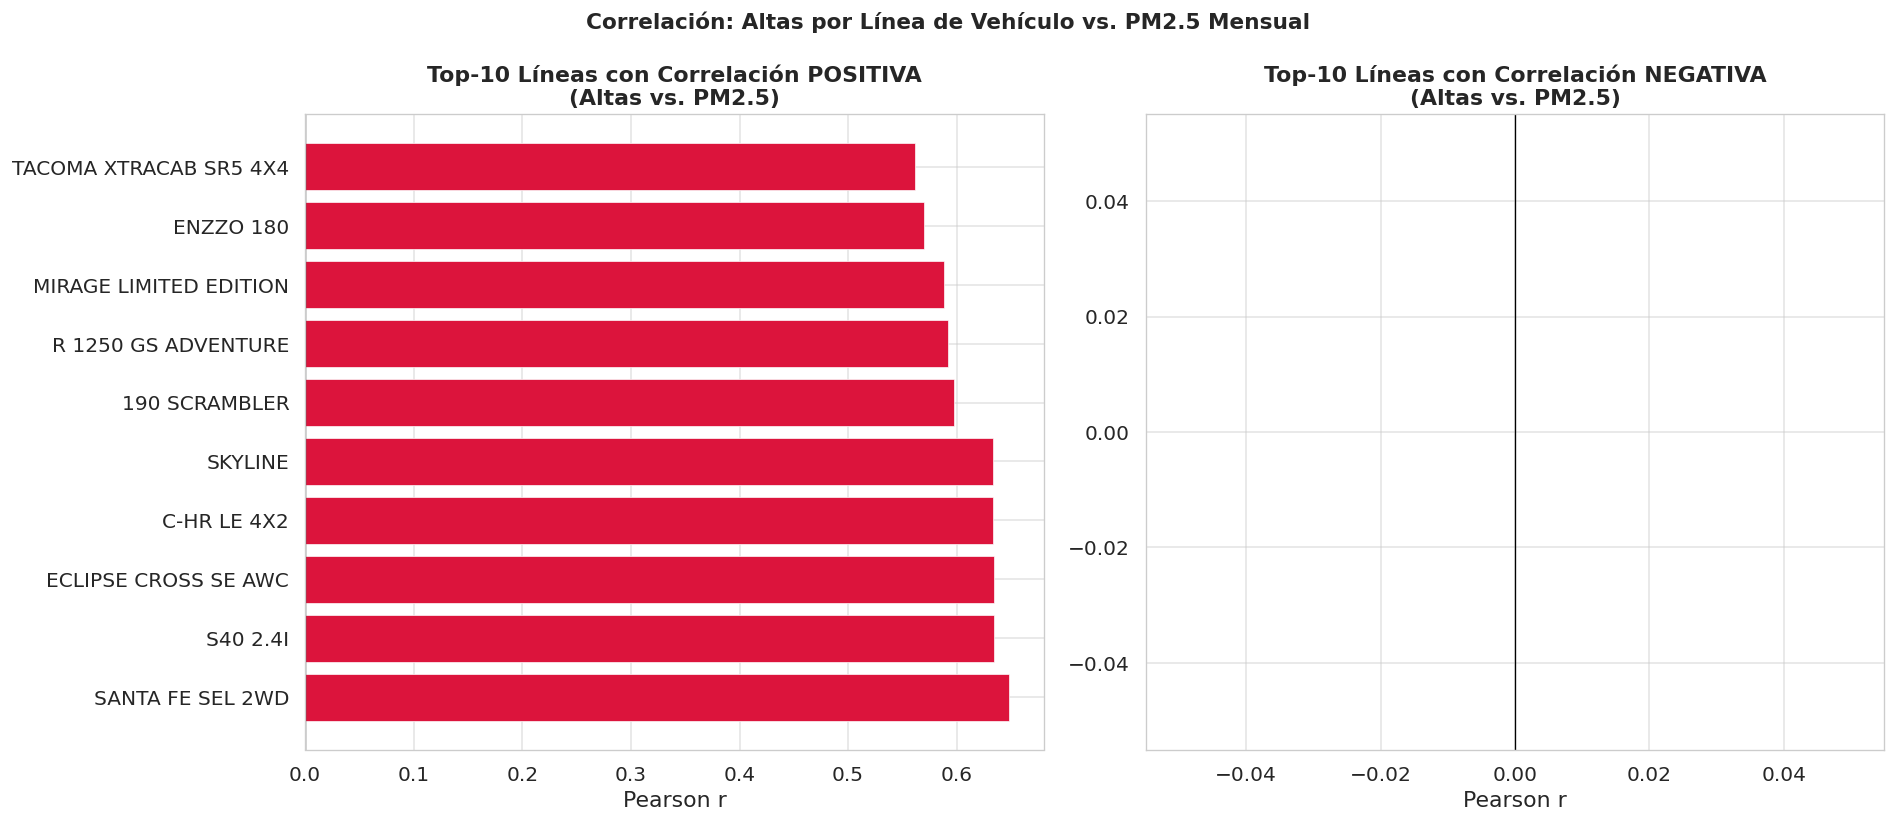

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positivas más fuertes
top_pos = corr_alta_linea[corr_alta_linea['Correlación'] > 0].head(10)
axes[0].barh(top_pos['Segmento'], top_pos['Correlación'], color='crimson', edgecolor='white', linewidth=0.4)
axes[0].set_title('Top-10 Líneas con Correlación POSITIVA\n(Altas vs. PM2.5)', fontweight='bold')
axes[0].set_xlabel('Pearson r'); axes[0].axvline(0, color='black', linewidth=0.8)

# Negativas más fuertes
top_neg = corr_alta_linea[corr_alta_linea['Correlación'] < 0].sort_values('Correlación').head(10)
axes[1].barh(top_neg['Segmento'], top_neg['Correlación'], color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_title('Top-10 Líneas con Correlación NEGATIVA\n(Altas vs. PM2.5)', fontweight='bold')
axes[1].set_xlabel('Pearson r'); axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Correlación: Altas por Línea de Vehículo vs. PM2.5 Mensual', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/corr_alta_linea.png', bbox_inches='tight')
plt.show()

---
### Objetivo Específico 2 — Comparación interanual: PM2.5 vs. parque liviano por tipo de vehículo

Se compara, año por año (2022–2025), el nivel medio de PM2.5 frente al volumen
de altas del parque liviano desagregado por **tipo de vehículo**. Esto responde
directamente al objetivo: relacionar la evolución anual de la calidad del aire
con la composición del parque por tipo.

Tipos de vehículo con mayor volumen 2022-2025: ['MOTO', 'CAMIONETA', 'AUTOMOVIL', 'PICK UP', 'TRIMOTO', 'PANEL']


,MOTO,CAMIONETA,AUTOMOVIL,PICK UP,TRIMOTO,PANEL,TOTAL_ALTAS,PM25_MEDIO
ANIO,,,,,,,,
2022,64218,17013,9563,5628,1399,830,101541,25.86
2023,66394,21264,11728,6528,1359,974,111361,29.99
2024,81018,22099,12794,6759,3286,1057,130304,41.98
2025,93846,21817,11851,7388,4812,1070,144381,20.62


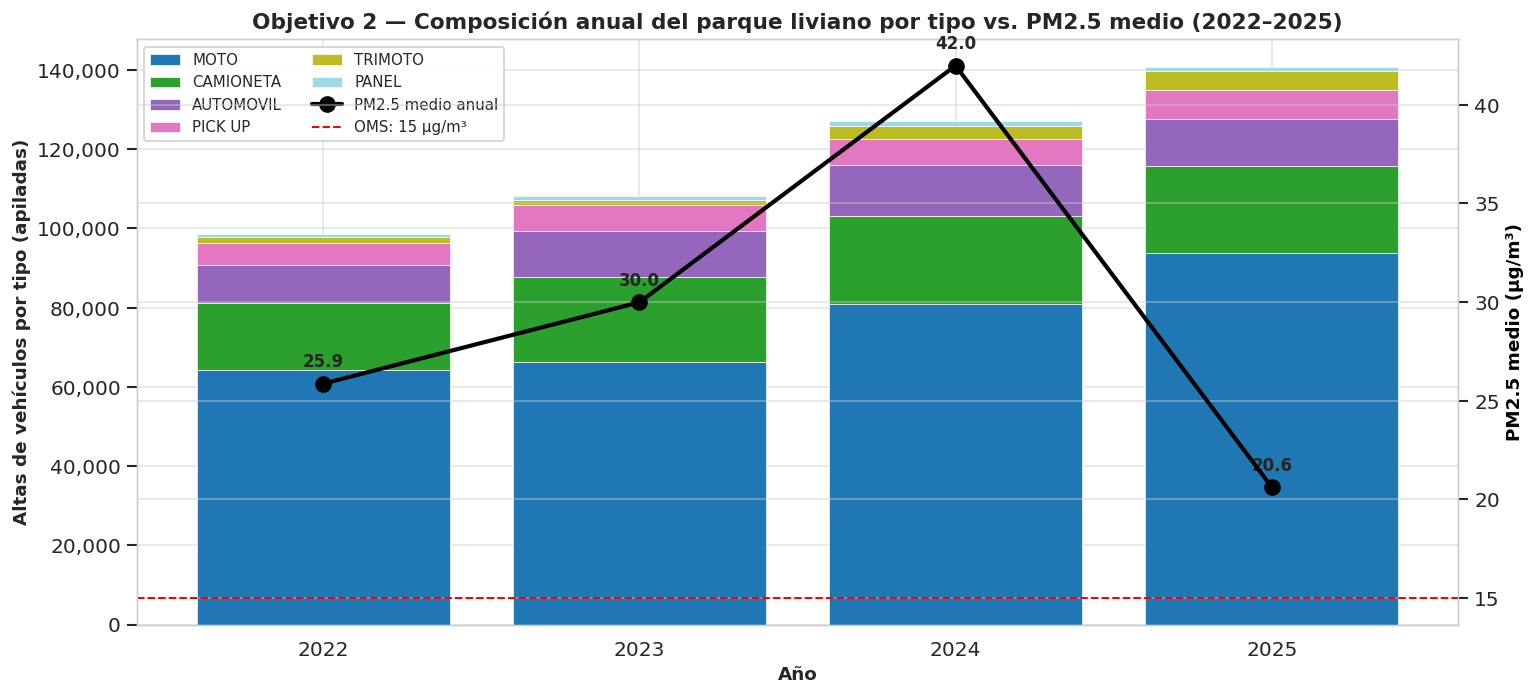

In [51]:
# ── OBJETIVO 2: PM2.5 medio por año vs. altas por TIPO de vehículo por año ──
# 1) PM2.5 medio anual
pm_anual = (df_merged.groupby('ANIO')['PM25_MEAN'].mean()
            .reset_index().rename(columns={'PM25_MEAN':'PM25_MEDIO'}))

# 2) Altas por tipo y año (usa el pivote de altas por tipo ya construido)
altas_tipo_anual = pivot_alta_tipo.copy()
altas_tipo_anual['ANIO'] = altas_tipo_anual.index.year
altas_tipo_anual = altas_tipo_anual.groupby('ANIO').sum()

# 3) Quedarse con los tipos más relevantes (mayor volumen total) para legibilidad
top_tipos = altas_tipo_anual.sum().sort_values(ascending=False).head(6).index.tolist()
print("Tipos de vehículo con mayor volumen 2022-2025:", top_tipos)

# 4) Tabla comparativa consolidada
tabla_obj2 = altas_tipo_anual[top_tipos].copy()
tabla_obj2['TOTAL_ALTAS'] = altas_tipo_anual.sum(axis=1)
tabla_obj2 = tabla_obj2.merge(pm_anual.set_index('ANIO'), left_index=True, right_index=True)
display(tabla_obj2.style.format('{:,.0f}', subset=top_tipos + ['TOTAL_ALTAS'])
        .format({'PM25_MEDIO':'{:.2f}'})
        .set_caption('Comparación anual: altas por tipo de vehículo vs. PM2.5 medio'))

# 5) Visualización: barras de altas por tipo (eje izq) + línea PM2.5 medio (eje der)
fig, ax1 = plt.subplots(figsize=(13, 6))
anios_x = tabla_obj2.index.astype(str)
bottom = np.zeros(len(tabla_obj2))
colores_t = plt.cm.tab20(np.linspace(0, 1, len(top_tipos)))
for tipo, col in zip(top_tipos, colores_t):
    ax1.bar(anios_x, tabla_obj2[tipo], bottom=bottom, label=tipo, color=col, edgecolor='white', linewidth=0.4)
    bottom += tabla_obj2[tipo].values
ax1.set_ylabel('Altas de vehículos por tipo (apiladas)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Año', fontsize=11, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(anios_x, tabla_obj2['PM25_MEDIO'], color='black', marker='o', markersize=9,
         linewidth=2.5, label='PM2.5 medio anual', zorder=5)
for x, y in zip(anios_x, tabla_obj2['PM25_MEDIO']):
    ax2.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 10),
                 ha='center', fontweight='bold', fontsize=10)
ax2.axhline(15, color='red', linestyle='--', linewidth=1.2, label='OMS: 15 μg/m³')
ax2.set_ylabel('PM2.5 medio (μg/m³)', fontsize=11, fontweight='bold', color='black')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9, framealpha=0.9, ncol=2)
plt.title('Objetivo 2 — Composición anual del parque liviano por tipo vs. PM2.5 medio (2022–2025)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./Output/obj2_tipo_vs_pm25_anual.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Objetivo Específico 3 — Incidencia del tipo de vehículo sobre el PM2.5 mensual

"Determinar la incidencia" exige aislar el efecto de cada tipo de vehículo
controlando por los demás, no una correlación bivariada (espuria sobre niveles).
Se ajusta una **regresión lineal múltiple** sobre las series **diferenciadas**
(estacionarias) de las altas por tipo de vehículo frente a la diferencia de
PM2.5. Cada coeficiente representa la incidencia marginal de ese tipo,
controlando por el resto. Se reporta el R² y la significancia individual.

> Nota: con n≈45 observaciones mensuales, el modelo se limita a los tipos de
> mayor volumen para evitar sobreajuste. Es un estimador de asociación
> condicional, no de causalidad estricta.

In [52]:
# ── OBJETIVO 3: incidencia marginal del TIPO de vehículo sobre ΔPM2.5 ──────
import statsmodels.api as sm

# Series diferenciadas (estacionarias) alineadas por período
pm_serie = df_merged.set_index('PERIOD')['PM25_MEAN']
d_pm_obj3 = pm_serie.diff()

# Altas por tipo, diferenciadas; usar los tipos de mayor volumen (top_tipos del obj 2)
X = pivot_alta_tipo[top_tipos].diff()

# Unir y limpiar NaN
data_obj3 = X.join(d_pm_obj3.rename('D_PM25'), how='inner').dropna()
print(f"Observaciones para el modelo de incidencia: {len(data_obj3)}")

Xm = sm.add_constant(data_obj3[top_tipos])
ym = data_obj3['D_PM25']
modelo_tipo = sm.OLS(ym, Xm).fit()
print(modelo_tipo.summary())

# Tabla de incidencia ordenada por magnitud del efecto
incidencia = (pd.DataFrame({
        'Tipo de vehículo': modelo_tipo.params.index,
        'Coeficiente (incidencia)': modelo_tipo.params.values,
        'p-valor': modelo_tipo.pvalues.values})
    .query("`Tipo de vehículo` != 'const'")
    .assign(Significativa=lambda d: np.where(d['p-valor'] < 0.05, 'Sí', 'No'))
    .sort_values('Coeficiente (incidencia)', key=abs, ascending=False)
    .reset_index(drop=True))

display(incidencia.style
        .background_gradient(subset=['Coeficiente (incidencia)'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'Coeficiente (incidencia)':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption(f'Incidencia marginal del tipo de vehículo sobre ΔPM2.5 (R²={modelo_tipo.rsquared:.3f})'))

print(f"\nR² del modelo: {modelo_tipo.rsquared:.4f}  |  R² ajustado: {modelo_tipo.rsquared_adj:.4f}")
print(f"F-test global p-valor: {modelo_tipo.f_pvalue:.4f}")
if modelo_tipo.f_pvalue >= 0.05:
    print("→ Conjuntamente, los tipos de vehículo NO explican la variación mensual de PM2.5.")
    print("  Hallazgo válido: a escala mensual el tipo de vehículo no incide significativamente,")
    print("  consistente con el dominio de factores climáticos/estacionales.")
else:
    print("→ El conjunto de tipos SÍ aporta poder explicativo; revisar coeficientes individuales.")

Observaciones para el modelo de incidencia: 47
                            OLS Regression Results                            
Dep. Variable:                 D_PM25   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     1.263
Date:                Tue, 30 Jun 2026   Prob (F-statistic):              0.296
Time:                        09:17:54   Log-Likelihood:                -194.31
No. Observations:                  47   AIC:                             402.6
Df Residuals:                      40   BIC:                             415.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

,Tipo de vehículo,Coeficiente (incidencia),p-valor,Significativa
0,PANEL,-0.2223,0.0240,Sí
1,CAMIONETA,0.0175,0.2713,No
2,AUTOMOVIL,0.0147,0.5285,No
3,TRIMOTO,-0.0101,0.5649,No
4,PICK UP,0.0001,0.9965,No
5,MOTO,0.0001,0.9432,No



R² del modelo: 0.1593  |  R² ajustado: 0.0332
F-test global p-valor: 0.2961
→ Conjuntamente, los tipos de vehículo NO explican la variación mensual de PM2.5.
  Hallazgo válido: a escala mensual el tipo de vehículo no incide significativamente,
  consistente con el dominio de factores climáticos/estacionales.


### Resumen consolidado de correlaciones

Se genera una tabla sintética con los hallazgos clave de los seis análisis de correlación para facilitar la redacción de la discusión en la tesis.

In [53]:
def top_hallazgo(df_corr, label):
    row = df_corr.iloc[0]
    return {'Análisis': label,
            'Segmento más correlacionado': row['Segmento'],
            'ρ / r': round(row['Correlación'], 4),
            'p-valor': round(row['p-valor'], 4),
            'Significativa': row['Significativa']}

resumen = pd.DataFrame([
    top_hallazgo(corr_acum_modelo, '1.1 Acumulado × Modelo Fabricación'),
    top_hallazgo(corr_acum_tipo,   '1.2 Acumulado × Tipo Vehículo'),
    top_hallazgo(corr_acum_linea,  '1.3 Acumulado × Línea Vehículo'),
    top_hallazgo(corr_alta_modelo, '2.1 Altas × Modelo Fabricación'),
    top_hallazgo(corr_alta_tipo,   '2.2 Altas × Tipo Vehículo'),
    top_hallazgo(corr_alta_linea,  '2.3 Altas × Línea Vehículo'),
])
display(resumen.style
        .background_gradient(subset=['ρ / r'], cmap='RdYlGn', vmin=-1, vmax=1)
        .format({'ρ / r':'{:.4f}','p-valor':'{:.4f}'})
        .set_caption('Tabla Síntesis — Hallazgos de Correlación por Segmentación'))

,Análisis,Segmento más correlacionado,ρ / r,p-valor,Significativa
0,1.1 Acumulado × Modelo Fabricación,2026,-0.2986,0.0392,Sí
1,1.2 Acumulado × Tipo Vehículo,CAMIONETA AGRICOLA,-0.2644,0.0694,No
2,1.3 Acumulado × Línea Vehículo,S10 LS 2WD,-0.4475,0.0014,Sí
3,2.1 Altas × Modelo Fabricación,2024,0.3999,0.0049,Sí
4,2.2 Altas × Tipo Vehículo,PANEL,-0.3351,0.0199,Sí
5,2.3 Altas × Línea Vehículo,SANTA FE SEL 2WD,0.6480,0.0000,Sí


## Conclusiones del Análisis

1. **ARIMA vs SARIMAX:** Se compara la línea base ARIMA contra un SARIMAX que
   incorpora como variable exógena el **crecimiento mensual del parque
   circulante** (stock diferenciado), no las altas mensuales. La superioridad
   del SARIMAX **no se asume**: se decide empíricamente por AIC/BIC/RMSE en la
   Fase 5 y se verifica antes la identificabilidad del modelo (errores estándar
   finitos, AIC en rango razonable). Si el SARIMAX no mejora al ARIMA, se
   reporta como hallazgo válido: a escala mensual, el volumen vehicular no
   aporta poder explicativo adicional sobre la dinámica intrínseca del PM2.5.

2. **Estacionariedad:** La prueba ADF confirma que PM2.5 es estacionaria
   (p≈0.007) mientras que el acumulado circulante es no estacionario (p≈1.0).
   Esta diferencia de orden de integración es la razón por la que la
   correlación directa entre ambas series en niveles resulta espuria y obliga a
   diferenciar o a usar cointegración.

3. **Correlación honesta (stock vs flujo):** La asociación se evalúa sobre
   series **diferenciadas** (estacionarias) y mediante el test de
   **cointegración de Engle-Granger**. Las altas (flujo marginal mensual) no
   son la variable físicamente relevante; el stock circulante sí, pero su
   relación con PM2.5 debe contrastarse correctamente, no por Pearson sobre
   niveles.

4. **Segmentos críticos (exploratorios):** Las correlaciones segmentadas por
   tipo, línea y año de fabricación se conservan como **exploración
   descriptiva** para señalar segmentos candidatos. Dado el problema de
   comparaciones múltiples y de regresión espuria, no constituyen evidencia
   causal y requieren re-evaluación diferenciada antes de fundamentar política
   pública.

5. **Limitaciones y siguiente paso:** Este análisis no establece causalidad.
   Faltan controles climáticos (temperatura, precipitación) e industriales/
   quemas agrícolas, que la evidencia previa sugiere dominantes —en particular
   la **temperatura**. La extensión natural es un modelo multivariante
   (SARIMAX o ECM) que incorpore `GAS_DATA` y variables climáticas como
   regresores exógenos adicionales; es probable que, controlando temperatura,
   el coeficiente vehicular se mantenga débil, lo cual sería un resultado
   legítimo y defendible para la tesis.

6. **Integridad de datos (correcciones aplicadas):** (a) se eliminó el outlier
   de PM2.5 de 1,016 µg/m³; (b) se descartó la imputación sintética de
   Ene/Feb 2022, trabajando con la serie real desde marzo 2022; (c) se corrigió
   el SARIMAX previamente degenerado (std err = 0, z = inf, AIC ≈ 1519).